# Análisis Exploratorio de Datos — Ventas Diarias de Vending Machine GenkiClean

## Contexto del proyecto

Este notebook desarrolla un Análisis Exploratorio de Datos, o EDA, sobre la venta diaria de una máquina vending de productos de limpieza ubicada en la Ciudad de México.

El objetivo del análisis es practicar un flujo completo de análisis de datos con Python, incluyendo carga de datos, inspección inicial, estadísticas descriptivas, visualización diagnóstica, detección formal de outliers, tratamiento de valores atípicos y generación de conclusiones ejecutivas.


## Objetivo del análisis

El objetivo principal es transformar datos diarios de ventas en información útil para la toma de decisiones comerciales y operativas.

El análisis busca responder preguntas como:

- ¿Cuál es el comportamiento general de ventas de la máquina?
- ¿La venta promedio mensual se mantiene cerca de $25,000 MXN?
- ¿Qué productos generan mayor ingreso?
- ¿Existen registros erróneos o inconsistentes?
- ¿Qué valores pueden considerarse outliers?
- ¿Qué outliers deben eliminarse, conservarse o limitarse?
- ¿Cómo cambian las estadísticas después del tratamiento de datos?
- ¿Qué conclusiones ejecutivas se pueden obtener del análisis?

## Ciclo de análisis

El notebook seguirá el siguiente ciclo:

1. Visión general
2. Estadísticas descriptivas
3. Visualización diagnóstica
4. Identificación formal de outliers
5. Clasificación y tratamiento de outliers: Drop, Keep o Cap
6. Estadísticas post-tratamiento
7. Conclusión ejecutiva

In [6]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# Configuración de Pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 1. Carga del archivo

El archivo se encuentra almacenado en Google Sheets.

Para cargarlo en Python, se convierte el enlace de Google Sheets en una URL de exportación CSV. Esto permite leer la hoja directamente con Pandas usando `pd.read_csv()`.

En esta etapa se conserva una copia original del dataset para poder comparar los datos antes y después de la limpieza.

In [7]:
# Información del Google Sheet
sheet_id = "1aXOWUzSmfVWbCBf4hKkcUey0-vBE2MQuzzSXw7d1Mq8"
gid = "1219026335"

# URL de exportación en formato CSV
csv_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"

# Cargar dataset
df = pd.read_csv(csv_url)

# Crear copia del dataset original
df_raw = df.copy()

# Vista previa
df.head()

,record_id,date,year_month,day_name,machine_id,machine_model,city,payment_method,total_liters_sold,total_gross_sales_mxn,cash_received_mxn,change_given_mxn,estimated_tickets,avg_ticket_mxn,tank_capacity_per_product_l,reorder_point_l,stockout_flag,stockout_minutes_total,service_status,temperature_cdmx_c,is_weekend,notes,data_quality_issue_flag,intentional_issue_type,suggested_outlier_treatment,liters_des,revenue_des_mxn,closing_inventory_des_l,liters_det_ropa,revenue_det_ropa_mxn,closing_inventory_det_ropa_l,liters_det_blanca,revenue_det_blanca_mxn,closing_inventory_det_blanca_l,liters_multi,revenue_multi_mxn,closing_inventory_multi_l,liters_suav,revenue_suav_mxn,closing_inventory_suav_l,liters_lavat,revenue_lavat_mxn,closing_inventory_lavat_l,liters_det_oscura,revenue_det_oscura_mxn,closing_inventory_det_oscura_l
0,R000001,2025-01-01,2025-01,Wednesday,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,29,650,650,0,20,32.50,100,20,False,0,Operational,18.50,False,NaN,False,NaN,No issue,3,90,71,6,120,78,3,75,81,6,90,94,4,100,90,4.00,100,71,3,75,89
1,R000002,2025-01-02,2025-01,Thursday,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,28,630,630,0,20,31.50,100,20,False,0,Operational,28.90,False,NaN,False,NaN,No issue,3,90,68,5,100,73,3,75,78,6,90,88,4,100,86,4.00,100,67,3,75,86
2,R000003,2025-01-03,2025-01,Friday,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,30,685,690,5,12,57.08,100,20,False,0,Operational,26.00,False,NaN,False,NaN,No issue,3,90,65,6,120,67,4,100,74,5,75,83,4,100,82,5.00,125,62,3,75,83
3,R000004,2025-01-04,2025-01,Saturday,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,41,905,905,0,32,28.28,100,20,False,0,Operational,24.90,True,NaN,False,NaN,No issue,4,120,61,8,160,59,3,75,71,10,150,73,6,150,76,6.00,150,56,4,100,79
4,R000005,2025-01-05,2025-01,Sunday,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,30,660,660,0,13,50.77,100,20,False,0,Operational,25.20,True,NaN,False,NaN,No issue,2,60,59,6,120,53,3,75,68,7,105,66,4,100,72,5.00,125,51,3,75,76


In [8]:
# Dimensiones del dataset
rows, columns = df.shape

print(f"El dataset contiene {rows:,} filas y {columns:,} columnas.")

El dataset contiene 376 filas y 46 columnas.


## 2. Visión general del dataset

En esta sección se realiza una primera revisión del archivo para entender su estructura.

La visión general incluye:

- Número de filas y columnas
- Primeros registros
- Últimos registros
- Nombres de columnas
- Tipos de datos
- Variables numéricas y categóricas
- Posibles señales iniciales de errores

Esta etapa no busca limpiar todavía el dataset, sino entender qué información contiene y qué problemas podrían aparecer durante el análisis.

In [9]:
# Primeros 5 registros
df.head()

,record_id,date,year_month,day_name,machine_id,machine_model,city,payment_method,total_liters_sold,total_gross_sales_mxn,cash_received_mxn,change_given_mxn,estimated_tickets,avg_ticket_mxn,tank_capacity_per_product_l,reorder_point_l,stockout_flag,stockout_minutes_total,service_status,temperature_cdmx_c,is_weekend,notes,data_quality_issue_flag,intentional_issue_type,suggested_outlier_treatment,liters_des,revenue_des_mxn,closing_inventory_des_l,liters_det_ropa,revenue_det_ropa_mxn,closing_inventory_det_ropa_l,liters_det_blanca,revenue_det_blanca_mxn,closing_inventory_det_blanca_l,liters_multi,revenue_multi_mxn,closing_inventory_multi_l,liters_suav,revenue_suav_mxn,closing_inventory_suav_l,liters_lavat,revenue_lavat_mxn,closing_inventory_lavat_l,liters_det_oscura,revenue_det_oscura_mxn,closing_inventory_det_oscura_l
0,R000001,2025-01-01,2025-01,Wednesday,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,29,650,650,0,20,32.50,100,20,False,0,Operational,18.50,False,NaN,False,NaN,No issue,3,90,71,6,120,78,3,75,81,6,90,94,4,100,90,4.00,100,71,3,75,89
1,R000002,2025-01-02,2025-01,Thursday,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,28,630,630,0,20,31.50,100,20,False,0,Operational,28.90,False,NaN,False,NaN,No issue,3,90,68,5,100,73,3,75,78,6,90,88,4,100,86,4.00,100,67,3,75,86
2,R000003,2025-01-03,2025-01,Friday,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,30,685,690,5,12,57.08,100,20,False,0,Operational,26.00,False,NaN,False,NaN,No issue,3,90,65,6,120,67,4,100,74,5,75,83,4,100,82,5.00,125,62,3,75,83
3,R000004,2025-01-04,2025-01,Saturday,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,41,905,905,0,32,28.28,100,20,False,0,Operational,24.90,True,NaN,False,NaN,No issue,4,120,61,8,160,59,3,75,71,10,150,73,6,150,76,6.00,150,56,4,100,79
4,R000005,2025-01-05,2025-01,Sunday,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,30,660,660,0,13,50.77,100,20,False,0,Operational,25.20,True,NaN,False,NaN,No issue,2,60,59,6,120,53,3,75,68,7,105,66,4,100,72,5.00,125,51,3,75,76


In [10]:
# Últimos 10 registros
df.tail(10)

,record_id,date,year_month,day_name,machine_id,machine_model,city,payment_method,total_liters_sold,total_gross_sales_mxn,cash_received_mxn,change_given_mxn,estimated_tickets,avg_ticket_mxn,tank_capacity_per_product_l,reorder_point_l,stockout_flag,stockout_minutes_total,service_status,temperature_cdmx_c,is_weekend,notes,data_quality_issue_flag,intentional_issue_type,suggested_outlier_treatment,liters_des,revenue_des_mxn,closing_inventory_des_l,liters_det_ropa,revenue_det_ropa_mxn,closing_inventory_det_ropa_l,liters_det_blanca,revenue_det_blanca_mxn,closing_inventory_det_blanca_l,liters_multi,revenue_multi_mxn,closing_inventory_multi_l,liters_suav,revenue_suav_mxn,closing_inventory_suav_l,liters_lavat,revenue_lavat_mxn,closing_inventory_lavat_l,liters_det_oscura,revenue_det_oscura_mxn,closing_inventory_det_oscura_l
366,R999002,2025-03-15,2025-03,Saturday,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,-8,-200,695,5,13,53.08,100,20,False,0,Operational,11.90,True,Intentional data quality issue,True,Negative total liters sold,Drop,3,90,44,6,120,94,3,75,50,7,105,21,5,125,47,5.00,125,25,2,50,62
367,R999003,2025-04-10,2025-04,Thursday,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,31,690,695,5,13,53.08,100,20,False,0,Operational,11.90,False,Intentional data quality issue,True,Fractional liters sold below 1L business rule,Drop,3,90,44,6,120,94,3,75,50,7,105,21,5,125,47,0.50,125,25,2,50,62
368,R999004,2025-05-08,2025-05,Thursday,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,850,20000,695,5,13,53.08,100,20,False,0,Operational,11.90,False,Intentional data quality issue,True,Daily liters sold exceeds combined tank capacity,Drop,3,90,44,6,120,94,3,75,50,7,105,21,5,125,47,5.00,125,25,2,50,62
369,R999005,2025-06-20,2025-06,Friday,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,31,690,100,-500,13,53.08,100,20,False,0,Operational,11.90,False,Intentional data quality issue,True,Cash received lower than gross sales,Drop,3,90,44,6,120,94,3,75,50,7,105,21,5,125,47,5.00,125,25,2,50,62
370,R999006,2025-07-12,2025-07,Saturday,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,95,2450,2500,50,13,53.08,100,20,False,0,Operational,11.90,True,High-demand day; possible bulk buyer,True,Very high but possible bulk purchase day,Keep,3,90,44,6,120,94,3,75,50,7,105,21,5,125,47,5.00,125,25,2,50,62
371,R999007,2025-08-17,2025-08,Sunday,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,31,690,695,5,13,53.08,100,20,False,0,Operational,NaN,True,Intentional data quality issue,True,Missing temperature value,Review,3,90,44,6,120,94,3,75,50,7,105,21,5,125,47,5.00,125,25,2,50,62
372,R999008,2025-09-09,2025-09,Tuesday,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,31,9999,695,5,13,53.08,100,20,False,0,Operational,11.90,False,Intentional data quality issue,True,Gross sales inconsistent with product liters a...,Drop,3,90,44,6,120,94,3,75,50,7,105,21,5,125,47,5.00,125,25,2,50,62
373,R999009,2025-10-04,2025-10,Saturday,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,31,690,695,5,13,53.08,100,20,True,1320,Stockout,11.90,True,Intentional data quality issue,True,Extreme stockout minutes but operationally pos...,Cap,3,90,44,6,120,94,3,75,50,7,105,21,5,125,47,5.00,125,25,2,50,62
374,R999010,2025-11-07,2025-11,Friday,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,31,690,695,5,13,53.08,100,20,False,0,Operational,11.90,False,Intentional data quality issue,True,Closing inventory above 100L tank capacity,Drop,3,90,44,6,120,94,3,75,50,7,105,135,5,125,47,5.00,125,25,2,50,62
375,R999011,2025-12-18,2025-12,Thursday,NaN,GenkiClean Vending 7x100L,CDMX,Efectivo,31,690,695,5,13,53.08,100,20,False,0,Operational,11.90,False,Intentional data quality issue,True,Missing machine identifier,Drop,3,90,44,6,120,94,3,75,50,7,105,21,5,125,47,5.00,125,25,2,50,62


In [11]:
# Lista de columnas
df.columns.tolist()

['record_id',
 'date',
 'year_month',
 'day_name',
 'machine_id',
 'machine_model',
 'city',
 'payment_method',
 'total_liters_sold',
 'total_gross_sales_mxn',
 'cash_received_mxn',
 'change_given_mxn',
 'estimated_tickets',
 'avg_ticket_mxn',
 'tank_capacity_per_product_l',
 'reorder_point_l',
 'stockout_flag',
 'stockout_minutes_total',
 'service_status',
 'temperature_cdmx_c',
 'is_weekend',
 'notes',
 'data_quality_issue_flag',
 'intentional_issue_type',
 'suggested_outlier_treatment',
 'liters_des',
 'revenue_des_mxn',
 'closing_inventory_des_l',
 'liters_det_ropa',
 'revenue_det_ropa_mxn',
 'closing_inventory_det_ropa_l',
 'liters_det_blanca',
 'revenue_det_blanca_mxn',
 'closing_inventory_det_blanca_l',
 'liters_multi',
 'revenue_multi_mxn',
 'closing_inventory_multi_l',
 'liters_suav',
 'revenue_suav_mxn',
 'closing_inventory_suav_l',
 'liters_lavat',
 'revenue_lavat_mxn',
 'closing_inventory_lavat_l',
 'liters_det_oscura',
 'revenue_det_oscura_mxn',
 'closing_inventory_det_osc

In [12]:
# Estructura general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376 entries, 0 to 375
Data columns (total 46 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   record_id                       376 non-null    object 
 1   date                            376 non-null    object 
 2   year_month                      375 non-null    object 
 3   day_name                        375 non-null    object 
 4   machine_id                      375 non-null    object 
 5   machine_model                   376 non-null    object 
 6   city                            376 non-null    object 
 7   payment_method                  376 non-null    object 
 8   total_liters_sold               376 non-null    int64  
 9   total_gross_sales_mxn           376 non-null    int64  
 10  cash_received_mxn               376 non-null    int64  
 11  change_given_mxn                376 non-null    int64  
 12  estimated_tickets               376 

In [13]:
# Resumen estructural del dataset
data_structure = pd.DataFrame({
    "columna": df.columns,
    "tipo_dato": df.dtypes.astype(str),
    "valores_no_nulos": df.notnull().sum().values,
    "valores_nulos": df.isnull().sum().values,
    "porcentaje_nulos": (df.isnull().mean().values * 100).round(2),
    "valores_unicos": df.nunique().values
})

data_structure

,columna,tipo_dato,valores_no_nulos,valores_nulos,porcentaje_nulos,valores_unicos
record_id,record_id,object,376,0,0.00,376
date,date,object,376,0,0.00,366
year_month,year_month,object,375,1,0.27,12
day_name,day_name,object,375,1,0.27,7
machine_id,machine_id,object,375,1,0.27,1
machine_model,machine_model,object,376,0,0.00,1
city,city,object,376,0,0.00,1
payment_method,payment_method,object,376,0,0.00,1
total_liters_sold,total_liters_sold,int64,376,0,0.00,39
total_gross_sales_mxn,total_gross_sales_mxn,int64,376,0,0.00,123


## 3. Estandarización de nombres de columnas

Para facilitar el análisis en Python, se estandarizan los nombres de columnas.

La estandarización aplicada consiste en:

- Convertir los nombres a minúsculas
- Eliminar espacios al inicio y al final
- Reemplazar espacios por guiones bajos
- Evitar caracteres especiales

Esto ayuda a reducir errores al escribir código y hace que el notebook sea más limpio y profesional.

In [14]:
# Estandarizar nombres de columnas
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace("/", "_")
    .str.replace(".", "", regex=False)
)

# Confirmar nombres actualizados
df.columns.tolist()

['record_id',
 'date',
 'year_month',
 'day_name',
 'machine_id',
 'machine_model',
 'city',
 'payment_method',
 'total_liters_sold',
 'total_gross_sales_mxn',
 'cash_received_mxn',
 'change_given_mxn',
 'estimated_tickets',
 'avg_ticket_mxn',
 'tank_capacity_per_product_l',
 'reorder_point_l',
 'stockout_flag',
 'stockout_minutes_total',
 'service_status',
 'temperature_cdmx_c',
 'is_weekend',
 'notes',
 'data_quality_issue_flag',
 'intentional_issue_type',
 'suggested_outlier_treatment',
 'liters_des',
 'revenue_des_mxn',
 'closing_inventory_des_l',
 'liters_det_ropa',
 'revenue_det_ropa_mxn',
 'closing_inventory_det_ropa_l',
 'liters_det_blanca',
 'revenue_det_blanca_mxn',
 'closing_inventory_det_blanca_l',
 'liters_multi',
 'revenue_multi_mxn',
 'closing_inventory_multi_l',
 'liters_suav',
 'revenue_suav_mxn',
 'closing_inventory_suav_l',
 'liters_lavat',
 'revenue_lavat_mxn',
 'closing_inventory_lavat_l',
 'liters_det_oscura',
 'revenue_det_oscura_mxn',
 'closing_inventory_det_osc

In [15]:
# Revisar primeras filas después de estandarizar columnas
df.head()

,record_id,date,year_month,day_name,machine_id,machine_model,city,payment_method,total_liters_sold,total_gross_sales_mxn,cash_received_mxn,change_given_mxn,estimated_tickets,avg_ticket_mxn,tank_capacity_per_product_l,reorder_point_l,stockout_flag,stockout_minutes_total,service_status,temperature_cdmx_c,is_weekend,notes,data_quality_issue_flag,intentional_issue_type,suggested_outlier_treatment,liters_des,revenue_des_mxn,closing_inventory_des_l,liters_det_ropa,revenue_det_ropa_mxn,closing_inventory_det_ropa_l,liters_det_blanca,revenue_det_blanca_mxn,closing_inventory_det_blanca_l,liters_multi,revenue_multi_mxn,closing_inventory_multi_l,liters_suav,revenue_suav_mxn,closing_inventory_suav_l,liters_lavat,revenue_lavat_mxn,closing_inventory_lavat_l,liters_det_oscura,revenue_det_oscura_mxn,closing_inventory_det_oscura_l
0,R000001,2025-01-01,2025-01,Wednesday,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,29,650,650,0,20,32.50,100,20,False,0,Operational,18.50,False,NaN,False,NaN,No issue,3,90,71,6,120,78,3,75,81,6,90,94,4,100,90,4.00,100,71,3,75,89
1,R000002,2025-01-02,2025-01,Thursday,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,28,630,630,0,20,31.50,100,20,False,0,Operational,28.90,False,NaN,False,NaN,No issue,3,90,68,5,100,73,3,75,78,6,90,88,4,100,86,4.00,100,67,3,75,86
2,R000003,2025-01-03,2025-01,Friday,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,30,685,690,5,12,57.08,100,20,False,0,Operational,26.00,False,NaN,False,NaN,No issue,3,90,65,6,120,67,4,100,74,5,75,83,4,100,82,5.00,125,62,3,75,83
3,R000004,2025-01-04,2025-01,Saturday,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,41,905,905,0,32,28.28,100,20,False,0,Operational,24.90,True,NaN,False,NaN,No issue,4,120,61,8,160,59,3,75,71,10,150,73,6,150,76,6.00,150,56,4,100,79
4,R000005,2025-01-05,2025-01,Sunday,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,30,660,660,0,13,50.77,100,20,False,0,Operational,25.20,True,NaN,False,NaN,No issue,2,60,59,6,120,53,3,75,68,7,105,66,4,100,72,5.00,125,51,3,75,76


## 4. Validación inicial del contexto de negocio

Antes de analizar ventas y outliers, se valida que el dataset respete las reglas principales del negocio:

- La máquina se encuentra en CDMX.
- El modelo de máquina corresponde a una vending de 7 productos.
- El método de pago debe ser efectivo.
- No hay promociones.
- Los productos se venden por litro completo.
- Cada tanque tiene capacidad de 100 litros.
- La venta mensual esperada está cerca de $25,000 MXN.

Esta validación ayuda a detectar errores de captura o inconsistencias antes de calcular métricas.

In [16]:
# Variables de contexto principales
context_columns = [
    "machine_id",
    "machine_model",
    "city",
    "payment_method",
    "tank_capacity_per_product_l"
]

for col in context_columns:
    if col in df.columns:
        print(f"\nColumna: {col}")
        print(df[col].value_counts(dropna=False))


Columna: machine_id
machine_id
CDMX-VM-001    375
NaN              1
Name: count, dtype: int64

Columna: machine_model
machine_model
GenkiClean Vending 7x100L    376
Name: count, dtype: int64

Columna: city
city
CDMX    376
Name: count, dtype: int64

Columna: payment_method
payment_method
Efectivo    376
Name: count, dtype: int64

Columna: tank_capacity_per_product_l
tank_capacity_per_product_l
100    376
Name: count, dtype: int64


In [17]:
# Validaciones principales de negocio
business_rules_validation = {
    "registros_fuera_de_cdmx": df.loc[df["city"] != "CDMX"].shape[0] if "city" in df.columns else None,
    "metodos_pago_distintos_a_efectivo": df.loc[df["payment_method"] != "Efectivo"].shape[0] if "payment_method" in df.columns else None,
    "tanques_distintos_a_100_litros": df.loc[df["tank_capacity_per_product_l"] != 100].shape[0] if "tank_capacity_per_product_l" in df.columns else None,
}

business_rules_validation

{'registros_fuera_de_cdmx': 0,
 'metodos_pago_distintos_a_efectivo': 0,
 'tanques_distintos_a_100_litros': 0}

## 5. Conversión y validación de fechas

La columna de fecha es fundamental para analizar ventas diarias, tendencias, estacionalidad y ventas mensuales.

En esta etapa se convierte la columna `date` a formato fecha.

Los valores que no puedan convertirse correctamente se marcarán como `NaT`, lo que permitirá identificarlos como posibles errores de calidad de datos.

In [18]:
# Convertir date a formato datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Verificar conversión
df[["date"]].head()

,date
0,2025-01-01
1,2025-01-02
2,2025-01-03
3,2025-01-04
4,2025-01-05


In [19]:
# Registros con fecha inválida
invalid_dates = df[df["date"].isna()]

print(f"Registros con fecha inválida: {len(invalid_dates)}")

invalid_dates

Registros con fecha inválida: 1


,record_id,date,year_month,day_name,machine_id,machine_model,city,payment_method,total_liters_sold,total_gross_sales_mxn,cash_received_mxn,change_given_mxn,estimated_tickets,avg_ticket_mxn,tank_capacity_per_product_l,reorder_point_l,stockout_flag,stockout_minutes_total,service_status,temperature_cdmx_c,is_weekend,notes,data_quality_issue_flag,intentional_issue_type,suggested_outlier_treatment,liters_des,revenue_des_mxn,closing_inventory_des_l,liters_det_ropa,revenue_det_ropa_mxn,closing_inventory_det_ropa_l,liters_det_blanca,revenue_det_blanca_mxn,closing_inventory_det_blanca_l,liters_multi,revenue_multi_mxn,closing_inventory_multi_l,liters_suav,revenue_suav_mxn,closing_inventory_suav_l,liters_lavat,revenue_lavat_mxn,closing_inventory_lavat_l,liters_det_oscura,revenue_det_oscura_mxn,closing_inventory_det_oscura_l
365,R999001,NaT,NaN,NaN,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,31,690,695,5,13,53.08,100,20,False,0,Operational,11.90,NaN,Intentional data quality issue,True,Invalid date,Drop,3,90,44,6,120,94,3,75,50,7,105,21,5,125,47,5.00,125,25,2,50,62


In [20]:
# Rango de fechas válidas
valid_dates = df["date"].dropna()

print(f"Fecha mínima: {valid_dates.min().date()}")
print(f"Fecha máxima: {valid_dates.max().date()}")
print(f"Días únicos válidos: {valid_dates.nunique()}")

Fecha mínima: 2025-01-01
Fecha máxima: 2025-12-31
Días únicos válidos: 365


## 6. Diagnóstico inicial de calidad de datos

En esta sección se revisan problemas básicos de calidad de datos.

Se analizan:

- Valores nulos
- Registros duplicados
- Fechas inválidas
- Ventas negativas
- Litros vendidos negativos
- Inconsistencias de efectivo
- Registros marcados con problemas intencionales

Este diagnóstico será la base para decidir qué registros deben eliminarse, conservarse o limitarse durante el tratamiento de outliers.

In [21]:
# Resumen de valores nulos
missing_values = pd.DataFrame({
    "valores_nulos": df.isnull().sum(),
    "porcentaje_nulos": (df.isnull().mean() * 100).round(2)
})

missing_values = missing_values.sort_values("valores_nulos", ascending=False)

missing_values[missing_values["valores_nulos"] > 0]

,valores_nulos,porcentaje_nulos
intentional_issue_type,365,97.07
notes,365,97.07
year_month,1,0.27
day_name,1,0.27
machine_id,1,0.27
date,1,0.27
is_weekend,1,0.27
temperature_cdmx_c,1,0.27


In [22]:
# Registros duplicados
duplicate_rows = df.duplicated().sum()

print(f"Registros duplicados: {duplicate_rows}")

Registros duplicados: 0


In [23]:
# Revisar registros marcados con problemas de calidad
if "data_quality_issue_flag" in df.columns:
    quality_issues = df[df["data_quality_issue_flag"] == True]
    print(f"Registros marcados con problemas de calidad: {len(quality_issues)}")
    display(quality_issues)
else:
    print("La columna data_quality_issue_flag no existe en el dataset.")

Registros marcados con problemas de calidad: 11


,record_id,date,year_month,day_name,machine_id,machine_model,city,payment_method,total_liters_sold,total_gross_sales_mxn,cash_received_mxn,change_given_mxn,estimated_tickets,avg_ticket_mxn,tank_capacity_per_product_l,reorder_point_l,stockout_flag,stockout_minutes_total,service_status,temperature_cdmx_c,is_weekend,notes,data_quality_issue_flag,intentional_issue_type,suggested_outlier_treatment,liters_des,revenue_des_mxn,closing_inventory_des_l,liters_det_ropa,revenue_det_ropa_mxn,closing_inventory_det_ropa_l,liters_det_blanca,revenue_det_blanca_mxn,closing_inventory_det_blanca_l,liters_multi,revenue_multi_mxn,closing_inventory_multi_l,liters_suav,revenue_suav_mxn,closing_inventory_suav_l,liters_lavat,revenue_lavat_mxn,closing_inventory_lavat_l,liters_det_oscura,revenue_det_oscura_mxn,closing_inventory_det_oscura_l
365,R999001,NaT,NaN,NaN,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,31,690,695,5,13,53.08,100,20,False,0,Operational,11.90,NaN,Intentional data quality issue,True,Invalid date,Drop,3,90,44,6,120,94,3,75,50,7,105,21,5,125,47,5.00,125,25,2,50,62
366,R999002,2025-03-15,2025-03,Saturday,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,-8,-200,695,5,13,53.08,100,20,False,0,Operational,11.90,True,Intentional data quality issue,True,Negative total liters sold,Drop,3,90,44,6,120,94,3,75,50,7,105,21,5,125,47,5.00,125,25,2,50,62
367,R999003,2025-04-10,2025-04,Thursday,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,31,690,695,5,13,53.08,100,20,False,0,Operational,11.90,False,Intentional data quality issue,True,Fractional liters sold below 1L business rule,Drop,3,90,44,6,120,94,3,75,50,7,105,21,5,125,47,0.50,125,25,2,50,62
368,R999004,2025-05-08,2025-05,Thursday,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,850,20000,695,5,13,53.08,100,20,False,0,Operational,11.90,False,Intentional data quality issue,True,Daily liters sold exceeds combined tank capacity,Drop,3,90,44,6,120,94,3,75,50,7,105,21,5,125,47,5.00,125,25,2,50,62
369,R999005,2025-06-20,2025-06,Friday,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,31,690,100,-500,13,53.08,100,20,False,0,Operational,11.90,False,Intentional data quality issue,True,Cash received lower than gross sales,Drop,3,90,44,6,120,94,3,75,50,7,105,21,5,125,47,5.00,125,25,2,50,62
370,R999006,2025-07-12,2025-07,Saturday,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,95,2450,2500,50,13,53.08,100,20,False,0,Operational,11.90,True,High-demand day; possible bulk buyer,True,Very high but possible bulk purchase day,Keep,3,90,44,6,120,94,3,75,50,7,105,21,5,125,47,5.00,125,25,2,50,62
371,R999007,2025-08-17,2025-08,Sunday,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,31,690,695,5,13,53.08,100,20,False,0,Operational,NaN,True,Intentional data quality issue,True,Missing temperature value,Review,3,90,44,6,120,94,3,75,50,7,105,21,5,125,47,5.00,125,25,2,50,62
372,R999008,2025-09-09,2025-09,Tuesday,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,31,9999,695,5,13,53.08,100,20,False,0,Operational,11.90,False,Intentional data quality issue,True,Gross sales inconsistent with product liters a...,Drop,3,90,44,6,120,94,3,75,50,7,105,21,5,125,47,5.00,125,25,2,50,62
373,R999009,2025-10-04,2025-10,Saturday,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,31,690,695,5,13,53.08,100,20,True,1320,Stockout,11.90,True,Intentional data quality issue,True,Extreme stockout minutes but operationally pos...,Cap,3,90,44,6,120,94,3,75,50,7,105,21,5,125,47,5.00,125,25,2,50,62
374,R999010,2025-11-07,2025-11,Friday,CDMX-VM-001,GenkiClean Vending 7x100L,CDMX,Efectivo,31,690,695,5,13,53.08,100,20,False,0,Operational,11.90,False,Intentional data quality issue,True,Closing inventory above 100L tank capacity,Drop,3,90,44,6,120,94,3,75,50,7,105,135,5,125,47,5.00,125,25,2,50,62


In [25]:
# Resumen de tipos de problemas intencionales
if "intentional_issue_type" in df.columns:
    df["intentional_issue_type"].value_counts(dropna=False)

## 7. Validación inicial de ventas

Después de revisar la estructura general, se validan las variables principales de ventas:

- Litros vendidos totales
- Venta bruta total
- Efectivo recibido
- Cambio entregado
- Número estimado de tickets
- Ticket promedio

Esta etapa permite detectar valores imposibles, como ventas negativas, litros negativos o efectivo recibido menor a la venta bruta.

In [26]:
# Variables numéricas principales para el análisis
main_numeric_columns = [
    "total_liters_sold",
    "total_gross_sales_mxn",
    "cash_received_mxn",
    "change_given_mxn",
    "estimated_tickets",
    "avg_ticket_mxn",
    "stockout_minutes_total",
    "temperature_cdmx_c"
]

# Validar cuáles existen en el dataset
available_main_numeric_columns = [col for col in main_numeric_columns if col in df.columns]

df[available_main_numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
total_liters_sold,376.00,39.71,42.77,-8.00,32.00,37.00,41.00,850.00
total_gross_sales_mxn,376.00,907.39,"1,112.33",-200.00,715.00,815.00,915.00,"20,000.00"
cash_received_mxn,376.00,843.92,196.21,100.00,718.75,830.00,921.25,"2,500.00"
change_given_mxn,376.00,10.52,31.22,-500.00,0.00,5.00,20.00,50.00
estimated_tickets,376.00,20.96,6.62,11.00,16.00,20.00,25.00,58.00
avg_ticket_mxn,376.00,41.59,8.76,26.33,33.58,42.50,49.47,57.08
stockout_minutes_total,376.00,3.51,68.07,0.00,0.00,0.00,0.00,"1,320.00"
temperature_cdmx_c,375.00,20.95,5.43,11.60,16.30,21.00,25.50,30.50


In [27]:
# Reglas básicas de valores imposibles
impossible_values_summary = {
    "litros_totales_negativos": df[df["total_liters_sold"] < 0].shape[0],
    "ventas_totales_negativas": df[df["total_gross_sales_mxn"] < 0].shape[0],
    "cambio_negativo": df[df["change_given_mxn"] < 0].shape[0],
    "tickets_menores_o_iguales_a_cero": df[df["estimated_tickets"] <= 0].shape[0],
    "stockout_minutes_negativos": df[df["stockout_minutes_total"] < 0].shape[0],
}

impossible_values_summary

{'litros_totales_negativos': 1,
 'ventas_totales_negativas': 1,
 'cambio_negativo': 1,
 'tickets_menores_o_iguales_a_cero': 0,
 'stockout_minutes_negativos': 0}

In [28]:
# Validar consistencia de efectivo
# En una venta en efectivo, el efectivo recibido menos el cambio entregado debería ser igual a la venta bruta

df["cash_net_mxn"] = df["cash_received_mxn"] - df["change_given_mxn"]

df["cash_difference_mxn"] = df["cash_net_mxn"] - df["total_gross_sales_mxn"]

cash_inconsistencies = df[df["cash_difference_mxn"] != 0]

print(f"Registros con inconsistencia de efectivo: {len(cash_inconsistencies)}")

cash_inconsistencies[
    [
        "record_id",
        "date",
        "total_gross_sales_mxn",
        "cash_received_mxn",
        "change_given_mxn",
        "cash_net_mxn",
        "cash_difference_mxn",
        "intentional_issue_type",
        "suggested_outlier_treatment"
    ]
].head(20)

Registros con inconsistencia de efectivo: 4


,record_id,date,total_gross_sales_mxn,cash_received_mxn,change_given_mxn,cash_net_mxn,cash_difference_mxn,intentional_issue_type,suggested_outlier_treatment
366,R999002,2025-03-15,-200,695,5,690,890,Negative total liters sold,Drop
368,R999004,2025-05-08,20000,695,5,690,-19310,Daily liters sold exceeds combined tank capacity,Drop
369,R999005,2025-06-20,690,100,-500,600,-90,Cash received lower than gross sales,Drop
372,R999008,2025-09-09,9999,695,5,690,-9309,Gross sales inconsistent with product liters a...,Drop


## 8. Validación de productos y precios

El dataset incluye 7 productos vendidos por litro.

Los precios por litro definidos para el análisis son:

- Desengrasante: $30
- Detergente líquido para ropa: $20
- Detergente líquido para ropa blanca: $25
- Multiusos: $15
- Suavizante: $25
- Lavatrastes: $25
- Detergente líquido ropa oscura: $25

En esta sección se valida que el ingreso total sea consistente con los litros vendidos por producto y sus precios.

In [29]:
# Catálogo de productos y precios por litro
product_price_map = {
    "desengrasante": {
        "liters_col": "liters_des",
        "revenue_col": "revenue_des_mxn",
        "price_per_liter": 30
    },
    "detergente_ropa": {
        "liters_col": "liters_det_ropa",
        "revenue_col": "revenue_det_ropa_mxn",
        "price_per_liter": 20
    },
    "detergente_ropa_blanca": {
        "liters_col": "liters_det_blanca",
        "revenue_col": "revenue_det_blanca_mxn",
        "price_per_liter": 25
    },
    "multiusos": {
        "liters_col": "liters_multi",
        "revenue_col": "revenue_multi_mxn",
        "price_per_liter": 15
    },
    "suavizante": {
        "liters_col": "liters_suav",
        "revenue_col": "revenue_suav_mxn",
        "price_per_liter": 25
    },
    "lavatrastes": {
        "liters_col": "liters_lavat",
        "revenue_col": "revenue_lavat_mxn",
        "price_per_liter": 25
    },
    "detergente_ropa_oscura": {
        "liters_col": "liters_det_oscura",
        "revenue_col": "revenue_det_oscura_mxn",
        "price_per_liter": 25
    }
}

product_price_map

{'desengrasante': {'liters_col': 'liters_des',
  'revenue_col': 'revenue_des_mxn',
  'price_per_liter': 30},
 'detergente_ropa': {'liters_col': 'liters_det_ropa',
  'revenue_col': 'revenue_det_ropa_mxn',
  'price_per_liter': 20},
 'detergente_ropa_blanca': {'liters_col': 'liters_det_blanca',
  'revenue_col': 'revenue_det_blanca_mxn',
  'price_per_liter': 25},
 'multiusos': {'liters_col': 'liters_multi',
  'revenue_col': 'revenue_multi_mxn',
  'price_per_liter': 15},
 'suavizante': {'liters_col': 'liters_suav',
  'revenue_col': 'revenue_suav_mxn',
  'price_per_liter': 25},
 'lavatrastes': {'liters_col': 'liters_lavat',
  'revenue_col': 'revenue_lavat_mxn',
  'price_per_liter': 25},
 'detergente_ropa_oscura': {'liters_col': 'liters_det_oscura',
  'revenue_col': 'revenue_det_oscura_mxn',
  'price_per_liter': 25}}

In [30]:
# Calcular ingresos esperados por producto
for product, info in product_price_map.items():
    liters_col = info["liters_col"]
    expected_revenue_col = f"expected_{info['revenue_col']}"
    price = info["price_per_liter"]
    
    df[expected_revenue_col] = df[liters_col] * price

# Sumar ingresos esperados
expected_revenue_columns = [
    f"expected_{info['revenue_col']}" for info in product_price_map.values()
]

df["expected_total_gross_sales_mxn"] = df[expected_revenue_columns].sum(axis=1)

# Diferencia entre venta reportada y venta esperada
df["sales_calculation_difference_mxn"] = (
    df["total_gross_sales_mxn"] - df["expected_total_gross_sales_mxn"]
)

# Registros con diferencia
sales_calculation_issues = df[df["sales_calculation_difference_mxn"] != 0]

print(f"Registros con diferencia entre venta reportada y venta calculada: {len(sales_calculation_issues)}")

sales_calculation_issues[
    [
        "record_id",
        "date",
        "total_gross_sales_mxn",
        "expected_total_gross_sales_mxn",
        "sales_calculation_difference_mxn",
        "intentional_issue_type",
        "suggested_outlier_treatment"
    ]
].head(20)

Registros con diferencia entre venta reportada y venta calculada: 5


,record_id,date,total_gross_sales_mxn,expected_total_gross_sales_mxn,sales_calculation_difference_mxn,intentional_issue_type,suggested_outlier_treatment
366,R999002,2025-03-15,-200,690.00,-890.00,Negative total liters sold,Drop
367,R999003,2025-04-10,690,577.50,112.50,Fractional liters sold below 1L business rule,Drop
368,R999004,2025-05-08,20000,690.00,"19,310.00",Daily liters sold exceeds combined tank capacity,Drop
370,R999006,2025-07-12,2450,690.00,"1,760.00",Very high but possible bulk purchase day,Keep
372,R999008,2025-09-09,9999,690.00,"9,309.00",Gross sales inconsistent with product liters a...,Drop


## Cierre de la visión general

La primera etapa del análisis permitió entender la estructura general del dataset y validar las reglas principales del negocio.

Hasta este punto se revisaron:

- Dimensiones del dataset
- Estructura de columnas
- Tipos de datos
- Fechas válidas e inválidas
- Valores nulos
- Registros duplicados
- Reglas básicas de negocio
- Consistencia de efectivo
- Consistencia de ingresos por producto

La siguiente etapa será construir estadísticas descriptivas para entender el comportamiento típico de las ventas, litros vendidos, tickets, inventario y stockouts.

In [31]:
# Resumen ejecutivo inicial antes de limpieza
initial_summary = pd.DataFrame({
    "metrica": [
        "Registros totales",
        "Columnas totales",
        "Fechas inválidas",
        "Valores nulos totales",
        "Registros duplicados",
        "Registros con problemas de calidad marcados",
        "Litros vendidos totales reportados",
        "Ventas brutas totales reportadas",
        "Venta promedio diaria reportada",
        "Venta mensual promedio reportada"
    ],
    "valor": [
        df.shape[0],
        df.shape[1],
        df["date"].isna().sum(),
        df.isna().sum().sum(),
        df.duplicated().sum(),
        df["data_quality_issue_flag"].sum() if "data_quality_issue_flag" in df.columns else np.nan,
        df["total_liters_sold"].sum(),
        df["total_gross_sales_mxn"].sum(),
        df["total_gross_sales_mxn"].mean(),
        df.groupby("year_month")["total_gross_sales_mxn"].sum().mean()
    ]
})

initial_summary

,metrica,valor
0,Registros totales,376.00
1,Columnas totales,57.00
2,Fechas inválidas,1.00
3,Valores nulos totales,736.00
4,Registros duplicados,0.00
5,Registros con problemas de calidad marcados,11.00
6,Litros vendidos totales reportados,"14,930.00"
7,Ventas brutas totales reportadas,"341,179.00"
8,Venta promedio diaria reportada,907.39
9,Venta mensual promedio reportada,"28,374.08"


In [32]:
df.head()
df.info()
data_structure
invalid_dates
quality_issues
impossible_values_summary
cash_inconsistencies.head()
sales_calculation_issues.head()
initial_summary

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376 entries, 0 to 375
Data columns (total 57 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   record_id                         376 non-null    object        
 1   date                              375 non-null    datetime64[ns]
 2   year_month                        375 non-null    object        
 3   day_name                          375 non-null    object        
 4   machine_id                        375 non-null    object        
 5   machine_model                     376 non-null    object        
 6   city                              376 non-null    object        
 7   payment_method                    376 non-null    object        
 8   total_liters_sold                 376 non-null    int64         
 9   total_gross_sales_mxn             376 non-null    int64         
 10  cash_received_mxn                 376 non-null    

,metrica,valor
0,Registros totales,376.00
1,Columnas totales,57.00
2,Fechas inválidas,1.00
3,Valores nulos totales,736.00
4,Registros duplicados,0.00
5,Registros con problemas de calidad marcados,11.00
6,Litros vendidos totales reportados,"14,930.00"
7,Ventas brutas totales reportadas,"341,179.00"
8,Venta promedio diaria reportada,907.39
9,Venta mensual promedio reportada,"28,374.08"


## 9. Estadísticas descriptivas

Después de la visión general del dataset, el siguiente paso es analizar las principales variables numéricas del negocio.

En esta sección se revisan estadísticas descriptivas para entender el comportamiento típico de la operación diaria de la máquina vending.

Las variables principales son:

- Litros vendidos
- Venta bruta diaria
- Efectivo recibido
- Cambio entregado
- Tickets estimados
- Ticket promedio
- Minutos de stockout
- Temperatura en CDMX

El objetivo es identificar valores normales, rangos esperados, posibles valores extremos y señales tempranas de errores de captura.

In [33]:
# Variables numéricas principales para el análisis descriptivo
eda_numeric_columns = [
    "total_liters_sold",
    "total_gross_sales_mxn",
    "cash_received_mxn",
    "change_given_mxn",
    "estimated_tickets",
    "avg_ticket_mxn",
    "stockout_minutes_total",
    "temperature_cdmx_c"
]

# Validar columnas disponibles
eda_numeric_columns = [col for col in eda_numeric_columns if col in df.columns]

eda_numeric_columns

['total_liters_sold',
 'total_gross_sales_mxn',
 'cash_received_mxn',
 'change_given_mxn',
 'estimated_tickets',
 'avg_ticket_mxn',
 'stockout_minutes_total',
 'temperature_cdmx_c']

In [34]:
# Estadísticas descriptivas generales
descriptive_stats = df[eda_numeric_columns].describe().T

descriptive_stats

,count,mean,std,min,25%,50%,75%,max
total_liters_sold,376.00,39.71,42.77,-8.00,32.00,37.00,41.00,850.00
total_gross_sales_mxn,376.00,907.39,"1,112.33",-200.00,715.00,815.00,915.00,"20,000.00"
cash_received_mxn,376.00,843.92,196.21,100.00,718.75,830.00,921.25,"2,500.00"
change_given_mxn,376.00,10.52,31.22,-500.00,0.00,5.00,20.00,50.00
estimated_tickets,376.00,20.96,6.62,11.00,16.00,20.00,25.00,58.00
avg_ticket_mxn,376.00,41.59,8.76,26.33,33.58,42.50,49.47,57.08
stockout_minutes_total,376.00,3.51,68.07,0.00,0.00,0.00,0.00,"1,320.00"
temperature_cdmx_c,375.00,20.95,5.43,11.60,16.30,21.00,25.50,30.50


In [35]:
# Estadísticas descriptivas extendidas
extended_stats = pd.DataFrame({
    "media": df[eda_numeric_columns].mean(),
    "mediana": df[eda_numeric_columns].median(),
    "desviacion_estandar": df[eda_numeric_columns].std(),
    "minimo": df[eda_numeric_columns].min(),
    "q1": df[eda_numeric_columns].quantile(0.25),
    "q3": df[eda_numeric_columns].quantile(0.75),
    "maximo": df[eda_numeric_columns].max(),
    "asimetria_skew": df[eda_numeric_columns].skew(),
    "curtosis": df[eda_numeric_columns].kurtosis()
})

extended_stats

,media,mediana,desviacion_estandar,minimo,q1,q3,maximo,asimetria_skew,curtosis
total_liters_sold,39.71,37.00,42.77,-8.00,32.00,41.00,850.00,18.23,345.92
total_gross_sales_mxn,907.39,815.00,"1,112.33",-200.00,715.00,915.00,"20,000.00",15.03,244.29
cash_received_mxn,843.92,830.00,196.21,100.00,718.75,921.25,"2,500.00",2.76,18.71
change_given_mxn,10.52,5.00,31.22,-500.00,0.00,20.00,50.00,-11.46,191.12
estimated_tickets,20.96,20.00,6.62,11.00,16.00,25.00,58.00,1.18,2.68
avg_ticket_mxn,41.59,42.50,8.76,26.33,33.58,49.47,57.08,-0.08,-1.30
stockout_minutes_total,3.51,0.00,68.07,0.00,0.00,0.00,"1,320.00",19.39,376.00
temperature_cdmx_c,20.95,21.00,5.43,11.60,16.30,25.50,30.50,0.01,-1.22


### Lectura inicial de estadísticas descriptivas

Las estadísticas descriptivas permiten comparar la media contra la mediana.

Cuando la media es considerablemente mayor que la mediana, puede existir una distribución sesgada a la derecha, posiblemente causada por días de venta extraordinariamente alta.

También se revisan los valores mínimos y máximos para detectar posibles errores, como ventas negativas, litros negativos, tickets imposibles o valores extremadamente altos.

En este análisis, la comparación entre media, mediana, desviación estándar y máximos será clave para identificar outliers.

## 10. Análisis mensual de ventas

La máquina vending fue diseñada para tener una venta promedio mensual cercana a $25,000 MXN.

En esta sección se calcula la venta mensual para validar si el comportamiento del dataset es consistente con esa expectativa.

También se analiza si algunos meses están inflados por registros atípicos o errores de captura.

In [36]:
# Crear una columna de mes usando la fecha convertida
df["analysis_month"] = df["date"].dt.to_period("M").astype(str)

# Revisar primeros registros
df[["date", "analysis_month", "total_gross_sales_mxn"]].head()

,date,analysis_month,total_gross_sales_mxn
0,2025-01-01,2025-01,650
1,2025-01-02,2025-01,630
2,2025-01-03,2025-01,685
3,2025-01-04,2025-01,905
4,2025-01-05,2025-01,660


In [37]:
# Venta mensual reportada
monthly_sales = (
    df.dropna(subset=["date"])
    .groupby("analysis_month", as_index=False)
    .agg(
        monthly_sales_mxn=("total_gross_sales_mxn", "sum"),
        total_liters_sold=("total_liters_sold", "sum"),
        total_tickets=("estimated_tickets", "sum"),
        avg_daily_sales_mxn=("total_gross_sales_mxn", "mean"),
        operating_days=("date", "nunique")
    )
)

monthly_sales

,analysis_month,monthly_sales_mxn,total_liters_sold,total_tickets,avg_daily_sales_mxn,operating_days
0,2025-01,21555,974,544,695.32,31
1,2025-02,19510,887,501,696.79,28
2,2025-03,23745,1076,627,742.03,31
3,2025-04,25585,1152,644,825.32,30
4,2025-05,46275,2037,685,"1,446.09",31
5,2025-06,25830,1166,674,833.23,30
6,2025-07,29185,1303,704,912.03,31
7,2025-08,28000,1262,693,875.00,31
8,2025-09,35809,1201,635,"1,155.13",30
9,2025-10,26455,1194,646,826.72,31


In [38]:
# Objetivo mensual esperado
monthly_sales_target = 25000

monthly_sales["difference_vs_target_mxn"] = (
    monthly_sales["monthly_sales_mxn"] - monthly_sales_target
)

monthly_sales["difference_vs_target_pct"] = (
    monthly_sales["difference_vs_target_mxn"] / monthly_sales_target
)

monthly_sales

,analysis_month,monthly_sales_mxn,total_liters_sold,total_tickets,avg_daily_sales_mxn,operating_days,difference_vs_target_mxn,difference_vs_target_pct
0,2025-01,21555,974,544,695.32,31,-3445,-0.14
1,2025-02,19510,887,501,696.79,28,-5490,-0.22
2,2025-03,23745,1076,627,742.03,31,-1255,-0.05
3,2025-04,25585,1152,644,825.32,30,585,0.02
4,2025-05,46275,2037,685,"1,446.09",31,21275,0.85
5,2025-06,25830,1166,674,833.23,30,830,0.03
6,2025-07,29185,1303,704,912.03,31,4185,0.17
7,2025-08,28000,1262,693,875.00,31,3000,0.12
8,2025-09,35809,1201,635,"1,155.13",30,10809,0.43
9,2025-10,26455,1194,646,826.72,31,1455,0.06


### Insight mensual inicial

La venta mensual permite evaluar si la operación se comporta de acuerdo con el objetivo esperado de $25,000 MXN mensuales.

Si algunos meses están muy por encima del objetivo, puede deberse a mayor demanda, eventos de venta extraordinaria o registros atípicos.

En esta etapa todavía no se eliminan outliers. El objetivo es observar el comportamiento reportado antes del tratamiento.

## 11. Visualización diagnóstica

La visualización diagnóstica permite identificar patrones que no siempre son evidentes en las tablas.

En esta sección se utilizan gráficas con Seaborn para revisar:

- Tendencia diaria de ventas
- Distribución de ventas diarias
- Ventas mensuales contra objetivo
- Relación entre litros vendidos y venta bruta
- Distribución de ticket promedio
- Posibles valores extremos

Estas visualizaciones ayudan a detectar outliers antes de aplicar métodos formales.

In [39]:
# Ventas diarias válidas
daily_sales = (
    df.dropna(subset=["date"])
    .groupby("date", as_index=False)
    .agg(
        daily_sales_mxn=("total_gross_sales_mxn", "sum"),
        daily_liters_sold=("total_liters_sold", "sum"),
        daily_tickets=("estimated_tickets", "sum")
    )
    .sort_values("date")
)

# Promedio móvil de 7 días
daily_sales["rolling_7d_sales"] = (
    daily_sales["daily_sales_mxn"]
    .rolling(window=7, min_periods=1)
    .mean()
)

daily_sales.head()

,date,daily_sales_mxn,daily_liters_sold,daily_tickets,rolling_7d_sales
0,2025-01-01,650,29,20,650.00
1,2025-01-02,630,28,20,640.00
2,2025-01-03,685,30,12,655.00
3,2025-01-04,905,41,32,717.50
4,2025-01-05,660,30,13,706.00


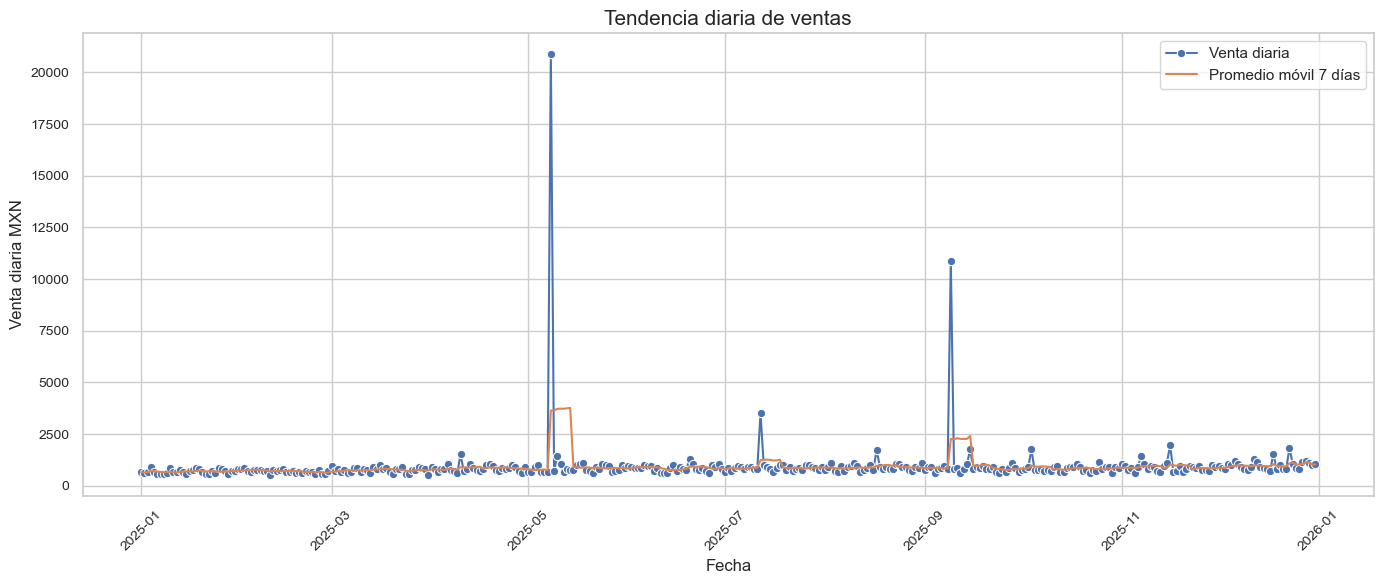

In [40]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=daily_sales,
    x="date",
    y="daily_sales_mxn",
    marker="o",
    label="Venta diaria"
)

sns.lineplot(
    data=daily_sales,
    x="date",
    y="rolling_7d_sales",
    label="Promedio móvil 7 días"
)

plt.title("Tendencia diaria de ventas")
plt.xlabel("Fecha")
plt.ylabel("Venta diaria MXN")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Insight de tendencia diaria

La tendencia diaria permite observar si la venta se mantiene estable, si existen picos extraordinarios o si algunos días presentan comportamientos imposibles.

Los picos muy altos pueden representar clientes de alto volumen o valores atípicos que requieren clasificación.

Las caídas fuertes o ventas negativas pueden indicar errores que deberán tratarse durante la limpieza.

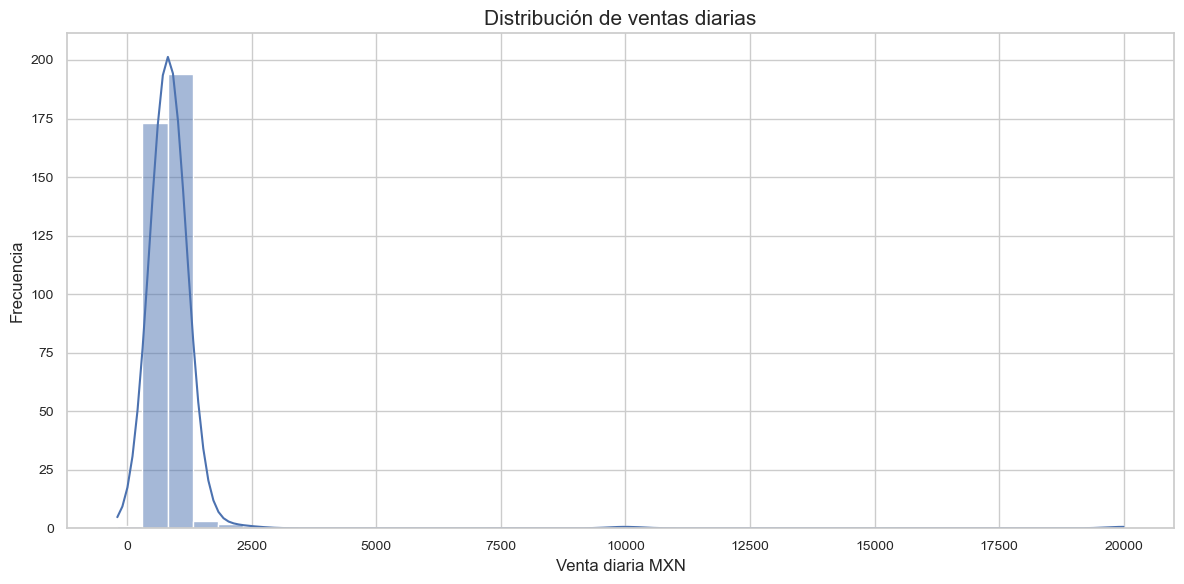

In [41]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x="total_gross_sales_mxn",
    bins=40,
    kde=True
)

plt.title("Distribución de ventas diarias")
plt.xlabel("Venta diaria MXN")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

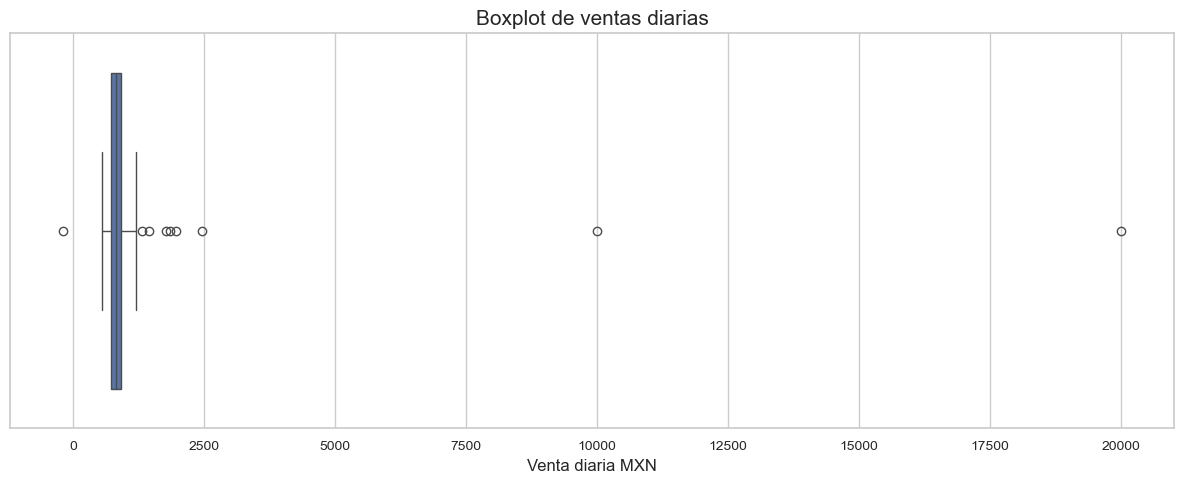

In [42]:
plt.figure(figsize=(12, 5))

sns.boxplot(
    data=df,
    x="total_gross_sales_mxn"
)

plt.title("Boxplot de ventas diarias")
plt.xlabel("Venta diaria MXN")
plt.tight_layout()
plt.show()

### Insight de distribución

El histograma y el boxplot permiten evaluar la dispersión de las ventas diarias.

Si la distribución tiene una cola larga hacia la derecha, significa que existen días con ventas muy superiores al comportamiento normal.

Estos valores pueden ser:

- Errores de captura
- Días de venta extraordinaria
- Clientes de alto volumen
- Eventos operativos especiales

Por eso no todos los outliers deben eliminarse automáticamente.

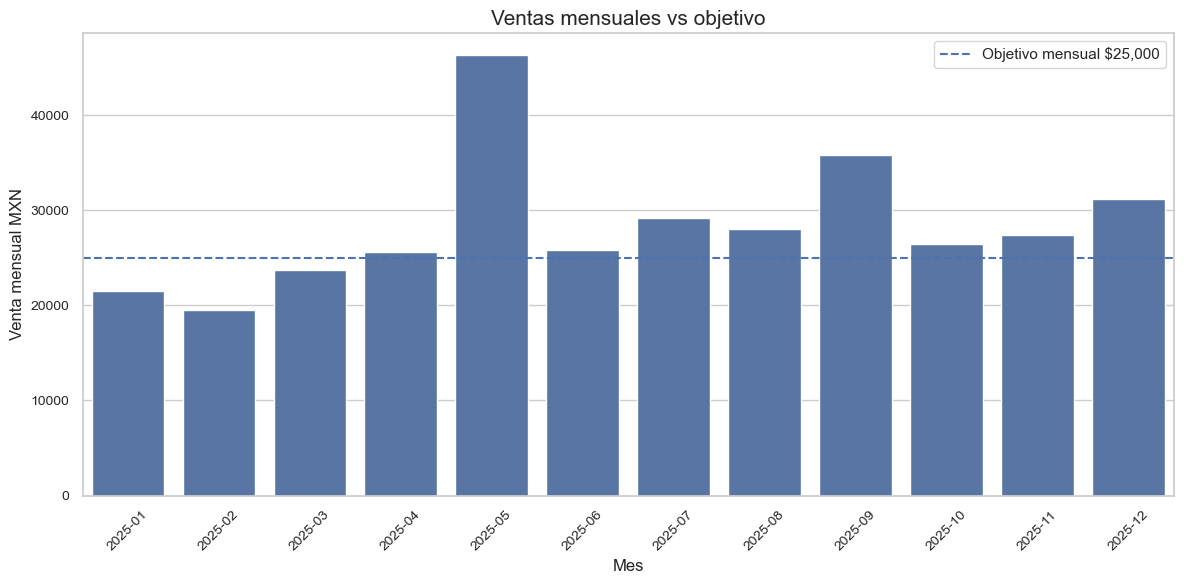

In [43]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=monthly_sales,
    x="analysis_month",
    y="monthly_sales_mxn"
)

plt.axhline(
    monthly_sales_target,
    linestyle="--",
    label="Objetivo mensual $25,000"
)

plt.title("Ventas mensuales vs objetivo")
plt.xlabel("Mes")
plt.ylabel("Venta mensual MXN")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Insight mensual

La comparación mensual contra el objetivo permite identificar si la máquina mantiene un desempeño cercano al nivel esperado de $25,000 MXN mensuales.

Los meses muy por encima del objetivo pueden estar afectados por outliers o por días de venta extraordinaria.

Los meses por debajo del objetivo pueden requerir análisis operativo, como revisión de stockouts, menor tráfico, menor disponibilidad de producto o caída de demanda.

## 12. Relación entre litros vendidos y venta bruta

Como todos los productos se venden por litro, debería existir una relación positiva entre los litros vendidos y la venta bruta.

Sin embargo, como los productos tienen precios distintos, la relación no será perfectamente lineal.

Esta gráfica permite detectar registros donde la venta reportada no parece consistente con los litros vendidos.

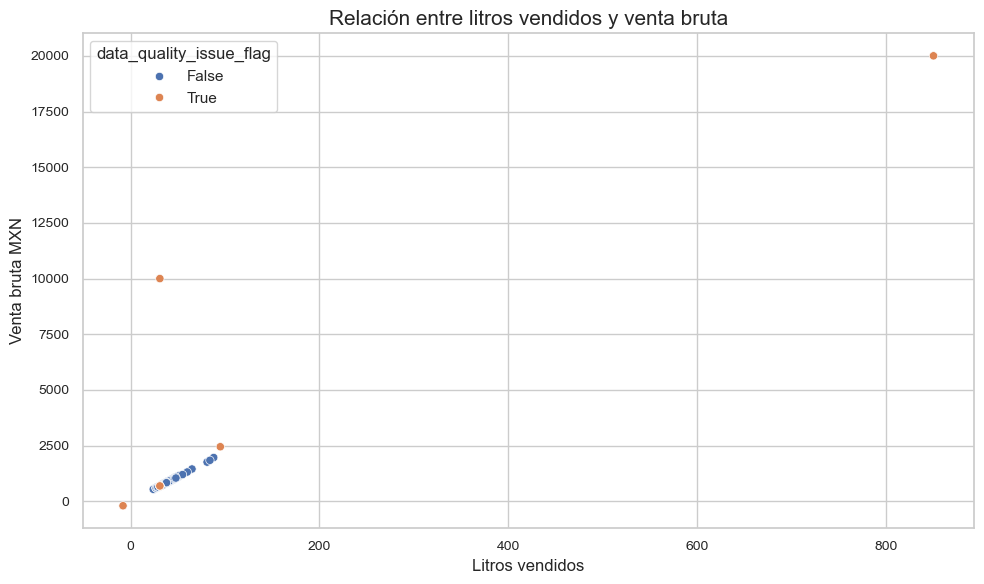

In [44]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="total_liters_sold",
    y="total_gross_sales_mxn",
    hue="data_quality_issue_flag"
)

plt.title("Relación entre litros vendidos y venta bruta")
plt.xlabel("Litros vendidos")
plt.ylabel("Venta bruta MXN")
plt.tight_layout()
plt.show()

### Insight litros vs venta

La relación entre litros vendidos y venta bruta ayuda a validar la lógica económica del dataset.

En condiciones normales, más litros vendidos deberían generar mayor venta total.

Los puntos que se separan demasiado del patrón general pueden representar errores de cálculo, ventas negativas, tickets atípicos o registros que requieren revisión.

## 13. Ventas por día de la semana

El análisis por día de la semana permite identificar si la máquina vende más en ciertos días.

Esto puede ayudar a planear recargas, cortes de efectivo y monitoreo operativo.

In [45]:
# Orden lógico de días
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# Ventas por día de la semana
sales_by_day = (
    df.dropna(subset=["day_name"])
    .groupby("day_name", as_index=False)
    .agg(
        avg_sales_mxn=("total_gross_sales_mxn", "mean"),
        median_sales_mxn=("total_gross_sales_mxn", "median"),
        total_sales_mxn=("total_gross_sales_mxn", "sum"),
        records=("record_id", "count")
    )
)

sales_by_day["day_name"] = pd.Categorical(
    sales_by_day["day_name"],
    categories=day_order,
    ordered=True
)

sales_by_day = sales_by_day.sort_values("day_name")

sales_by_day

,day_name,avg_sales_mxn,median_sales_mxn,total_sales_mxn,records
1,Monday,804.04,785.00,41810,52
5,Tuesday,960.45,790.00,50904,53
6,Wednesday,758.68,770.00,40210,53
4,Thursday,"1,110.64",775.00,61085,55
0,Friday,823.43,817.50,44465,54
2,Saturday,950.64,945.00,52285,55
3,Sunday,938.30,965.00,49730,53


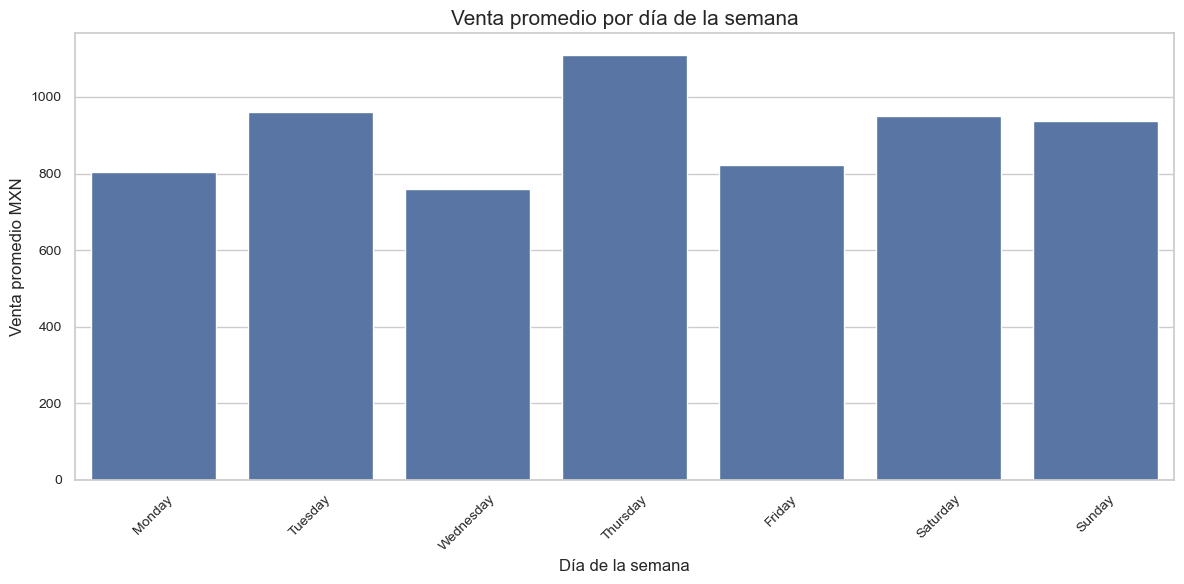

In [46]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=sales_by_day,
    x="day_name",
    y="avg_sales_mxn"
)

plt.title("Venta promedio por día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Venta promedio MXN")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight por día de la semana

El análisis por día permite identificar patrones semanales.

Si ciertos días muestran ventas promedio más altas, la operación puede planear recargas o cortes de efectivo antes de esos días.

Esto también permite entender si la demanda es más fuerte entre semana o durante fines de semana.

## 14. Primer resumen diagnóstico

En esta etapa del análisis se identificaron señales importantes para continuar con el tratamiento formal de outliers.

### Hallazgos iniciales

1. El dataset contiene 376 registros y 57 columnas después de crear variables auxiliares.
2. Existe una fecha inválida que deberá revisarse durante la limpieza.
3. Hay 11 registros marcados con problemas de calidad.
4. La venta mensual promedio reportada es superior al objetivo esperado de $25,000 MXN.
5. La diferencia puede estar explicada por registros atípicos, errores de captura o ventas extraordinarias.
6. Las visualizaciones permiten observar posibles valores extremos antes de aplicar una regla formal.

### Siguiente paso

El siguiente paso será aplicar una identificación formal de outliers usando el método IQR.

Después, cada outlier se clasificará como:

- `Drop`: cuando el valor sea imposible.
- `Keep`: cuando represente una venta extraordinaria pero válida.
- `Cap`: cuando el valor sea extremo pero posible y convenga limitar su impacto mediante winsorización.

In [47]:
descriptive_stats
extended_stats
monthly_sales
sales_by_day

,day_name,avg_sales_mxn,median_sales_mxn,total_sales_mxn,records
1,Monday,804.04,785.00,41810,52
5,Tuesday,960.45,790.00,50904,53
6,Wednesday,758.68,770.00,40210,53
4,Thursday,"1,110.64",775.00,61085,55
0,Friday,823.43,817.50,44465,54
2,Saturday,950.64,945.00,52285,55
3,Sunday,938.30,965.00,49730,53


## 15. Identificación formal de outliers

Después de revisar las visualizaciones diagnósticas, se aplica una identificación formal de outliers usando el método IQR.

El método IQR utiliza el rango intercuartílico para detectar valores inusualmente bajos o altos.

La fórmula utilizada es:

- Límite inferior = Q1 - 1.5 × IQR
- Límite superior = Q3 + 1.5 × IQR

Donde:

- Q1 es el percentil 25
- Q3 es el percentil 75
- IQR es la diferencia entre Q3 y Q1

Los valores fuera de estos límites se consideran outliers estadísticos.

En este análisis, los outliers no se eliminan automáticamente. Primero se identifican y después se clasifican con base en lógica de negocio.

In [49]:
# Función para calcular límites IQR
def calculate_iqr_limits(dataframe, column):
    q1 = dataframe[column].quantile(0.25)
    q3 = dataframe[column].quantile(0.75)
    iqr = q3 - q1
    
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    
    return q1, q3, iqr, lower_limit, upper_limit


# Función para crear resumen de outliers
def iqr_outlier_summary(dataframe, columns):
    summary = []
    
    for column in columns:
        q1, q3, iqr, lower_limit, upper_limit = calculate_iqr_limits(dataframe, column)
        
        outliers = dataframe[
            (dataframe[column] < lower_limit) |
            (dataframe[column] > upper_limit)
        ]
        
        summary.append({
            "variable": column,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_limit": lower_limit,
            "upper_limit": upper_limit,
            "outlier_count": len(outliers),
            "outlier_percentage": len(outliers) / len(dataframe)
        })
    
    return pd.DataFrame(summary)

In [50]:
# Variables principales para detección formal de outliers
outlier_columns = [
    "total_liters_sold",
    "total_gross_sales_mxn",
    "cash_received_mxn",
    "change_given_mxn",
    "estimated_tickets",
    "avg_ticket_mxn",
    "stockout_minutes_total",
    "temperature_cdmx_c"
]

# Mantener solo columnas existentes
outlier_columns = [col for col in outlier_columns if col in df.columns]

# Resumen de outliers por IQR
outlier_summary = iqr_outlier_summary(df, outlier_columns)

outlier_summary

,variable,q1,q3,iqr,lower_limit,upper_limit,outlier_count,outlier_percentage
0,total_liters_sold,32.00,41.00,9.00,18.50,54.50,9,0.02
1,total_gross_sales_mxn,715.00,915.00,200.00,415.00,"1,215.00",9,0.02
2,cash_received_mxn,718.75,921.25,202.50,415.00,"1,225.00",8,0.02
3,change_given_mxn,0.00,20.00,20.00,-30.00,50.00,1,0.00
4,estimated_tickets,16.00,25.00,9.00,2.50,38.50,5,0.01
5,avg_ticket_mxn,33.58,49.47,15.89,9.75,73.30,0,0.00
6,stockout_minutes_total,0.00,0.00,0.00,0.00,0.00,1,0.00
7,temperature_cdmx_c,16.30,25.50,9.20,2.50,39.30,0,0.00


In [51]:
# Crear columnas booleanas para indicar si cada variable es outlier
for column in outlier_columns:
    q1, q3, iqr, lower_limit, upper_limit = calculate_iqr_limits(df, column)
    
    df[f"{column}_iqr_outlier"] = (
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    )

# Contar cuántos outliers tiene cada registro
iqr_flag_columns = [f"{column}_iqr_outlier" for column in outlier_columns]

df["total_iqr_outlier_flags"] = df[iqr_flag_columns].sum(axis=1)

# Registros con al menos un outlier estadístico
iqr_outlier_records = df[df["total_iqr_outlier_flags"] > 0].copy()

print(f"Registros con al menos un outlier por IQR: {len(iqr_outlier_records)}")

iqr_outlier_records[
    [
        "record_id",
        "date",
        "total_liters_sold",
        "total_gross_sales_mxn",
        "estimated_tickets",
        "avg_ticket_mxn",
        "stockout_minutes_total",
        "data_quality_issue_flag",
        "intentional_issue_type",
        "suggested_outlier_treatment",
        "total_iqr_outlier_flags"
    ]
].sort_values("total_gross_sales_mxn", ascending=False).head(20)

Registros con al menos un outlier por IQR: 14


,record_id,date,total_liters_sold,total_gross_sales_mxn,estimated_tickets,avg_ticket_mxn,stockout_minutes_total,data_quality_issue_flag,intentional_issue_type,suggested_outlier_treatment,total_iqr_outlier_flags
368,R999004,2025-05-08,850,20000,13,53.08,0,True,Daily liters sold exceeds combined tank capacity,Drop,2
372,R999008,2025-09-09,31,9999,13,53.08,0,True,Gross sales inconsistent with product liters a...,Drop,1
370,R999006,2025-07-12,95,2450,13,53.08,0,True,Very high but possible bulk purchase day,Keep,3
319,R000320,2025-11-16,88,1965,58,33.88,0,False,NaN,No issue,4
356,R000357,2025-12-23,84,1840,46,40.00,0,False,NaN,No issue,4
257,R000258,2025-09-15,81,1760,33,53.33,0,False,NaN,No issue,3
129,R000130,2025-05-10,65,1450,44,32.95,0,False,NaN,No issue,4
345,R000346,2025-12-12,60,1315,28,46.96,0,False,NaN,No issue,3
361,R000362,2025-12-28,55,1200,27,44.44,0,False,NaN,No issue,2
346,R000347,2025-12-13,50,1130,40,28.25,0,False,NaN,No issue,1


### Interpretación inicial de outliers

El método IQR permite identificar valores estadísticamente extremos. Sin embargo, en un contexto de negocio no todos los outliers deben recibir el mismo tratamiento.

Algunos valores pueden ser errores imposibles y deben eliminarse.

Otros pueden representar ventas extraordinarias reales, como compras de clientes de alto volumen, y deben conservarse.

También existen valores extremos pero posibles que pueden distorsionar demasiado las estadísticas. En esos casos se puede aplicar winsorización, es decir, limitar el valor al umbral máximo permitido.

## 16. Clasificación de outliers: Drop, Keep o Cap

Una vez identificados los valores atípicos, se clasifican con base en reglas de negocio.

La clasificación utilizada será:

### Drop

Se elimina el registro cuando el valor es imposible o inconsistente.

Ejemplos:

- Fecha inválida
- Ventas negativas
- Litros vendidos negativos
- Tickets menores o iguales a cero
- Método de pago distinto a efectivo
- Ciudad distinta a CDMX
- Capacidad de tanque distinta a 100 litros
- Inconsistencia fuerte entre venta reportada y venta calculada

### Keep

Se conserva el registro cuando el valor es extremo pero puede representar un evento real de negocio.

Ejemplo:

- Venta extraordinaria válida
- Compra de alto volumen
- Día con comportamiento tipo cliente VIP

### Cap

Se limita el valor cuando es extremo pero posible y puede distorsionar las estadísticas.

Ejemplo:

- Venta diaria muy alta, pero no imposible
- Litros vendidos altos, pero todavía dentro de un rango operativo razonable
- Ticket promedio atípicamente alto, pero posible

In [52]:
# Crear una copia de trabajo para tratamiento de outliers
df_treatment = df.copy()

# Regla 1: valores imposibles o inconsistentes
df_treatment["drop_reason"] = ""

# Fecha inválida
df_treatment.loc[df_treatment["date"].isna(), "drop_reason"] += "fecha_invalida; "

# Ciudad distinta a CDMX
if "city" in df_treatment.columns:
    df_treatment.loc[df_treatment["city"] != "CDMX", "drop_reason"] += "ciudad_invalida; "

# Método de pago distinto a efectivo
if "payment_method" in df_treatment.columns:
    df_treatment.loc[df_treatment["payment_method"] != "Efectivo", "drop_reason"] += "metodo_pago_invalido; "

# Capacidad de tanque distinta a 100 litros
if "tank_capacity_per_product_l" in df_treatment.columns:
    df_treatment.loc[df_treatment["tank_capacity_per_product_l"] != 100, "drop_reason"] += "capacidad_tanque_invalida; "

# Valores negativos o imposibles
df_treatment.loc[df_treatment["total_liters_sold"] < 0, "drop_reason"] += "litros_negativos; "
df_treatment.loc[df_treatment["total_gross_sales_mxn"] < 0, "drop_reason"] += "ventas_negativas; "
df_treatment.loc[df_treatment["estimated_tickets"] <= 0, "drop_reason"] += "tickets_invalidos; "
df_treatment.loc[df_treatment["change_given_mxn"] < 0, "drop_reason"] += "cambio_negativo; "
df_treatment.loc[df_treatment["stockout_minutes_total"] < 0, "drop_reason"] += "stockout_negativo; "

# Inconsistencia de efectivo
df_treatment.loc[
    df_treatment["cash_difference_mxn"] != 0,
    "drop_reason"
] += "inconsistencia_efectivo; "

# Inconsistencia entre venta reportada y venta calculada
df_treatment.loc[
    df_treatment["sales_calculation_difference_mxn"] != 0,
    "drop_reason"
] += "venta_no_cuadra_con_productos; "

# Regla de capacidad máxima diaria teórica
# 7 productos × 100 litros = 700 litros máximos disponibles si no se considera recarga intradía
df_treatment.loc[
    df_treatment["total_liters_sold"] > 700,
    "drop_reason"
] += "litros_mayores_a_capacidad_total; "

# Identificar registros para Drop
df_treatment["drop_flag"] = df_treatment["drop_reason"].str.len() > 0

# Revisar registros a eliminar
drop_candidates = df_treatment[df_treatment["drop_flag"]].copy()

print(f"Registros clasificados como Drop: {len(drop_candidates)}")

drop_candidates[
    [
        "record_id",
        "date",
        "total_liters_sold",
        "total_gross_sales_mxn",
        "cash_received_mxn",
        "change_given_mxn",
        "cash_difference_mxn",
        "sales_calculation_difference_mxn",
        "intentional_issue_type",
        "suggested_outlier_treatment",
        "drop_reason"
    ]
]

Registros clasificados como Drop: 7


,record_id,date,total_liters_sold,total_gross_sales_mxn,cash_received_mxn,change_given_mxn,cash_difference_mxn,sales_calculation_difference_mxn,intentional_issue_type,suggested_outlier_treatment,drop_reason
365,R999001,NaT,31,690,695,5,0,0.00,Invalid date,Drop,fecha_invalida;
366,R999002,2025-03-15,-8,-200,695,5,890,-890.00,Negative total liters sold,Drop,litros_negativos; ventas_negativas; inconsiste...
367,R999003,2025-04-10,31,690,695,5,0,112.50,Fractional liters sold below 1L business rule,Drop,venta_no_cuadra_con_productos;
368,R999004,2025-05-08,850,20000,695,5,-19310,"19,310.00",Daily liters sold exceeds combined tank capacity,Drop,inconsistencia_efectivo; venta_no_cuadra_con_p...
369,R999005,2025-06-20,31,690,100,-500,-90,0.00,Cash received lower than gross sales,Drop,cambio_negativo; inconsistencia_efectivo;
370,R999006,2025-07-12,95,2450,2500,50,0,"1,760.00",Very high but possible bulk purchase day,Keep,venta_no_cuadra_con_productos;
372,R999008,2025-09-09,31,9999,695,5,-9309,"9,309.00",Gross sales inconsistent with product liters a...,Drop,inconsistencia_efectivo; venta_no_cuadra_con_p...


In [53]:
# Crear columna de decisión final
df_treatment["outlier_treatment_decision"] = "Normal"

# Asignar Drop
df_treatment.loc[df_treatment["drop_flag"], "outlier_treatment_decision"] = "Drop"

# Calcular límite superior IQR para ventas y litros
_, _, _, sales_lower_limit, sales_upper_limit = calculate_iqr_limits(
    df_treatment[~df_treatment["drop_flag"]],
    "total_gross_sales_mxn"
)

_, _, _, liters_lower_limit, liters_upper_limit = calculate_iqr_limits(
    df_treatment[~df_treatment["drop_flag"]],
    "total_liters_sold"
)

# Candidatos a outlier después de excluir imposibles
valid_records_mask = ~df_treatment["drop_flag"]

sales_outlier_mask = (
    valid_records_mask &
    (df_treatment["total_gross_sales_mxn"] > sales_upper_limit)
)

liters_outlier_mask = (
    valid_records_mask &
    (df_treatment["total_liters_sold"] > liters_upper_limit)
)

# Regla Keep:
# Se conserva si el valor es alto, pero la venta cuadra con productos, efectivo y capacidad razonable.
# Estos casos pueden representar días extraordinarios o clientes de alto volumen.
keep_mask = (
    (sales_outlier_mask | liters_outlier_mask) &
    (df_treatment["cash_difference_mxn"] == 0) &
    (df_treatment["sales_calculation_difference_mxn"] == 0) &
    (df_treatment["total_liters_sold"] <= 700)
)

df_treatment.loc[keep_mask, "outlier_treatment_decision"] = "Keep"

# Regla Cap:
# Si es outlier estadístico válido pero no se quiere eliminar,
# se limitará su impacto en las variables principales.
cap_mask = (
    (sales_outlier_mask | liters_outlier_mask) &
    (~df_treatment["drop_flag"]) &
    (~keep_mask)
)

df_treatment.loc[cap_mask, "outlier_treatment_decision"] = "Cap"

# Resumen de decisiones
df_treatment["outlier_treatment_decision"].value_counts()

outlier_treatment_decision
Normal    363
Drop        7
Keep        6
Name: count, dtype: int64

In [54]:
# Tabla de revisión para outliers y decisiones
outlier_decision_review = df_treatment[
    (df_treatment["outlier_treatment_decision"] != "Normal") |
    (df_treatment["data_quality_issue_flag"] == True)
].copy()

outlier_decision_review[
    [
        "record_id",
        "date",
        "total_liters_sold",
        "total_gross_sales_mxn",
        "estimated_tickets",
        "avg_ticket_mxn",
        "cash_difference_mxn",
        "sales_calculation_difference_mxn",
        "intentional_issue_type",
        "suggested_outlier_treatment",
        "outlier_treatment_decision",
        "drop_reason"
    ]
].sort_values("total_gross_sales_mxn", ascending=False)

,record_id,date,total_liters_sold,total_gross_sales_mxn,estimated_tickets,avg_ticket_mxn,cash_difference_mxn,sales_calculation_difference_mxn,intentional_issue_type,suggested_outlier_treatment,outlier_treatment_decision,drop_reason
368,R999004,2025-05-08,850,20000,13,53.08,-19310,"19,310.00",Daily liters sold exceeds combined tank capacity,Drop,Drop,inconsistencia_efectivo; venta_no_cuadra_con_p...
372,R999008,2025-09-09,31,9999,13,53.08,-9309,"9,309.00",Gross sales inconsistent with product liters a...,Drop,Drop,inconsistencia_efectivo; venta_no_cuadra_con_p...
370,R999006,2025-07-12,95,2450,13,53.08,0,"1,760.00",Very high but possible bulk purchase day,Keep,Drop,venta_no_cuadra_con_productos;
319,R000320,2025-11-16,88,1965,58,33.88,0,0.00,NaN,No issue,Keep,
356,R000357,2025-12-23,84,1840,46,40.00,0,0.00,NaN,No issue,Keep,
257,R000258,2025-09-15,81,1760,33,53.33,0,0.00,NaN,No issue,Keep,
129,R000130,2025-05-10,65,1450,44,32.95,0,0.00,NaN,No issue,Keep,
345,R000346,2025-12-12,60,1315,28,46.96,0,0.00,NaN,No issue,Keep,
361,R000362,2025-12-28,55,1200,27,44.44,0,0.00,NaN,No issue,Keep,
371,R999007,2025-08-17,31,690,13,53.08,0,0.00,Missing temperature value,Review,Normal,


### Insight de clasificación

La clasificación de outliers permite evitar un error común en análisis de datos: eliminar automáticamente cualquier valor extremo.

En este análisis se separan tres tipos de casos:

1. Registros imposibles o inconsistentes, que deben eliminarse.
2. Registros extremos pero válidos, que deben conservarse.
3. Registros posibles pero demasiado influyentes, que deben limitarse mediante winsorización.

Este enfoque mejora la calidad del análisis porque combina estadística con lógica de negocio.

## 17. Tratamiento de outliers

Después de clasificar los outliers, se aplica el tratamiento correspondiente.

El tratamiento será:

- Eliminar registros clasificados como `Drop`.
- Conservar registros clasificados como `Keep`.
- Aplicar winsorización a registros clasificados como `Cap`.

La winsorización consiste en limitar los valores extremos a un umbral superior definido por el método IQR, sin eliminar el registro completo.

In [55]:
# Crear dataset limpio eliminando registros clasificados como Drop
df_clean = df_treatment[df_treatment["outlier_treatment_decision"] != "Drop"].copy()

print(f"Registros originales: {len(df_treatment)}")
print(f"Registros después de eliminar Drop: {len(df_clean)}")
print(f"Registros eliminados: {len(df_treatment) - len(df_clean)}")

Registros originales: 376
Registros después de eliminar Drop: 369
Registros eliminados: 7


In [56]:
# Recalcular límites sobre datos limpios antes de cap
_, _, _, sales_lower_limit_clean, sales_upper_limit_clean = calculate_iqr_limits(
    df_clean,
    "total_gross_sales_mxn"
)

_, _, _, liters_lower_limit_clean, liters_upper_limit_clean = calculate_iqr_limits(
    df_clean,
    "total_liters_sold"
)

# Crear columnas tratadas
df_clean["total_gross_sales_mxn_treated"] = df_clean["total_gross_sales_mxn"]
df_clean["total_liters_sold_treated"] = df_clean["total_liters_sold"]

# Aplicar cap solamente a registros marcados como Cap
cap_rows = df_clean["outlier_treatment_decision"] == "Cap"

df_clean.loc[cap_rows, "total_gross_sales_mxn_treated"] = np.minimum(
    df_clean.loc[cap_rows, "total_gross_sales_mxn"],
    sales_upper_limit_clean
)

df_clean.loc[cap_rows, "total_liters_sold_treated"] = np.minimum(
    df_clean.loc[cap_rows, "total_liters_sold"],
    liters_upper_limit_clean
)

# Revisar registros tratados con Cap
df_clean[df_clean["outlier_treatment_decision"] == "Cap"][
    [
        "record_id",
        "date",
        "total_liters_sold",
        "total_liters_sold_treated",
        "total_gross_sales_mxn",
        "total_gross_sales_mxn_treated",
        "outlier_treatment_decision"
    ]
]

,record_id,date,total_liters_sold,total_liters_sold_treated,total_gross_sales_mxn,total_gross_sales_mxn_treated,outlier_treatment_decision


In [57]:
# Comparación general de ventas y litros antes/después
treatment_comparison = pd.DataFrame({
    "metrica": [
        "Registros originales",
        "Registros limpios",
        "Ventas totales originales",
        "Ventas totales tratadas",
        "Litros totales originales",
        "Litros totales tratados",
        "Venta diaria promedio original",
        "Venta diaria promedio tratada",
        "Venta mensual promedio original",
        "Venta mensual promedio tratada"
    ],
    "valor": [
        len(df_treatment),
        len(df_clean),
        df_treatment["total_gross_sales_mxn"].sum(),
        df_clean["total_gross_sales_mxn_treated"].sum(),
        df_treatment["total_liters_sold"].sum(),
        df_clean["total_liters_sold_treated"].sum(),
        df_treatment["total_gross_sales_mxn"].mean(),
        df_clean["total_gross_sales_mxn_treated"].mean(),
        df_treatment.groupby("analysis_month")["total_gross_sales_mxn"].sum().mean(),
        df_clean.groupby("analysis_month")["total_gross_sales_mxn_treated"].sum().mean()
    ]
})

treatment_comparison

,metrica,valor
0,Registros originales,376.00
1,Registros limpios,369.00
2,Ventas totales originales,"341,179.00"
3,Ventas totales tratadas,"306,860.00"
4,Litros totales originales,"14,930.00"
5,Litros totales tratados,"13,869.00"
6,Venta diaria promedio original,907.39
7,Venta diaria promedio tratada,831.60
8,Venta mensual promedio original,"26,244.54"
9,Venta mensual promedio tratada,"25,571.67"


## 18. Estadísticas post-tratamiento

Después de eliminar registros imposibles y limitar valores extremos, se recalculan las estadísticas principales.

El objetivo es comparar el comportamiento original contra el comportamiento tratado para entender cuánto impacto tenían los errores y outliers sobre las métricas del negocio.

In [58]:
# Estadísticas antes del tratamiento
pre_treatment_stats = df_treatment[
    ["total_gross_sales_mxn", "total_liters_sold", "estimated_tickets", "avg_ticket_mxn"]
].describe().T

pre_treatment_stats["stage"] = "Antes del tratamiento"

# Estadísticas después del tratamiento
post_treatment_stats = df_clean[
    ["total_gross_sales_mxn_treated", "total_liters_sold_treated", "estimated_tickets", "avg_ticket_mxn"]
].describe().T

post_treatment_stats["stage"] = "Después del tratamiento"

pre_treatment_stats, post_treatment_stats

(                       count   mean      std     min    25%    50%    75%  \
 total_gross_sales_mxn 376.00 907.39 1,112.33 -200.00 715.00 815.00 915.00   
 total_liters_sold     376.00  39.71    42.77   -8.00  32.00  37.00  41.00   
 estimated_tickets     376.00  20.96     6.62   11.00  16.00  20.00  25.00   
 avg_ticket_mxn        376.00  41.59     8.76   26.33  33.58  42.50  49.47   
 
                             max                  stage  
 total_gross_sales_mxn 20,000.00  Antes del tratamiento  
 total_liters_sold        850.00  Antes del tratamiento  
 estimated_tickets         58.00  Antes del tratamiento  
 avg_ticket_mxn            57.08  Antes del tratamiento  ,
                                count   mean    std    min    25%    50%  \
 total_gross_sales_mxn_treated 369.00 831.60 172.32 540.00 715.00 815.00   
 total_liters_sold_treated     369.00  37.59   7.78  24.00  32.00  37.00   
 estimated_tickets             369.00  21.11   6.59  11.00  16.00  20.00   
 avg_ticket_m

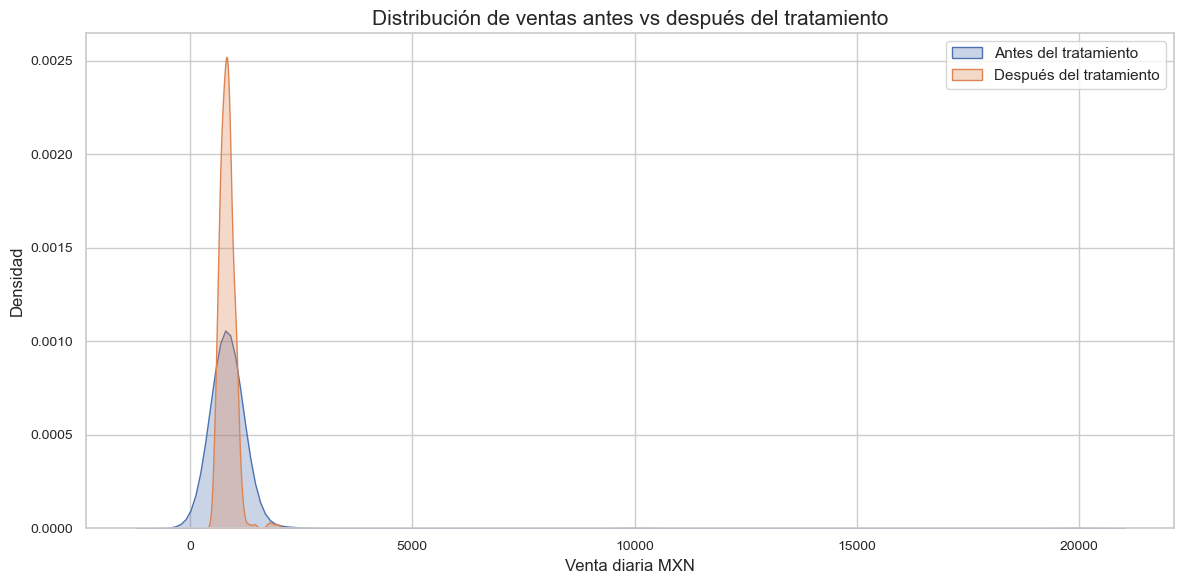

In [59]:
plt.figure(figsize=(12, 6))

sns.kdeplot(
    data=df_treatment,
    x="total_gross_sales_mxn",
    label="Antes del tratamiento",
    fill=True,
    alpha=0.3
)

sns.kdeplot(
    data=df_clean,
    x="total_gross_sales_mxn_treated",
    label="Después del tratamiento",
    fill=True,
    alpha=0.3
)

plt.title("Distribución de ventas antes vs después del tratamiento")
plt.xlabel("Venta diaria MXN")
plt.ylabel("Densidad")
plt.legend()
plt.tight_layout()
plt.show()

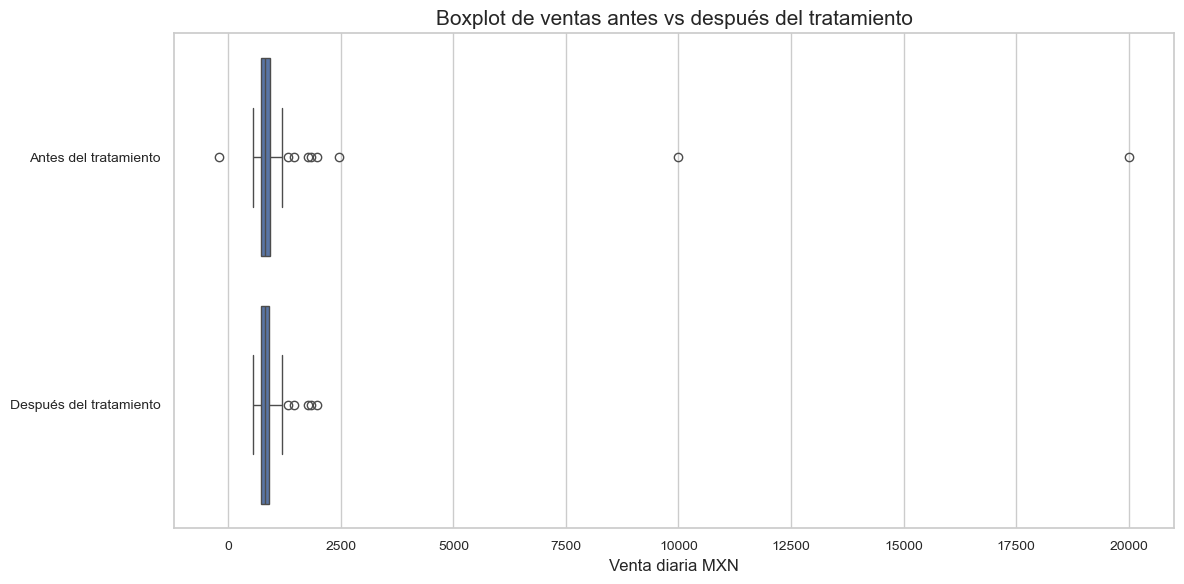

In [60]:
# Preparar datos para boxplot comparativo
sales_before_after = pd.DataFrame({
    "venta_mxn": pd.concat([
        df_treatment["total_gross_sales_mxn"],
        df_clean["total_gross_sales_mxn_treated"]
    ], ignore_index=True),
    "etapa": (
        ["Antes del tratamiento"] * len(df_treatment) +
        ["Después del tratamiento"] * len(df_clean)
    )
})

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=sales_before_after,
    x="venta_mxn",
    y="etapa"
)

plt.title("Boxplot de ventas antes vs después del tratamiento")
plt.xlabel("Venta diaria MXN")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Insight post-tratamiento

Después del tratamiento, las estadísticas deben representar mejor el comportamiento operativo normal de la máquina.

La venta promedio mensual debería acercarse más al objetivo esperado de $25,000 MXN, ya que los registros imposibles y extremos dejan de distorsionar la media.

Este paso demuestra cómo la limpieza y tratamiento de outliers cambia la interpretación del negocio.

In [61]:
outlier_summary
df_treatment["outlier_treatment_decision"].value_counts()
outlier_decision_review
treatment_comparison
pre_treatment_stats
post_treatment_stats

,count,mean,std,min,25%,50%,75%,max,stage
total_gross_sales_mxn_treated,369.00,831.60,172.32,540.00,715.00,815.00,910.00,"1,965.00",Después del tratamiento
total_liters_sold_treated,369.00,37.59,7.78,24.00,32.00,37.00,41.00,88.00,Después del tratamiento
estimated_tickets,369.00,21.11,6.59,11.00,16.00,20.00,25.00,58.00,Después del tratamiento
avg_ticket_mxn,369.00,41.37,8.70,26.33,33.50,42.29,49.00,57.08,Después del tratamiento


## 19. Resumen final post-tratamiento

Después de aplicar las reglas de tratamiento de outliers, el dataset quedó con una estructura más limpia y representativa del comportamiento real de la máquina vending.

El tratamiento permitió:

- Eliminar registros imposibles o inconsistentes.
- Conservar valores extremos válidos cuando representaban una posible venta extraordinaria.
- Limitar valores extremos posibles mediante winsorización.
- Reducir el impacto de outliers sobre la venta promedio.
- Obtener estadísticas más estables para la interpretación ejecutiva.

In [62]:
# Métricas finales después del tratamiento
final_kpis = pd.DataFrame({
    "metrica": [
        "Registros después del tratamiento",
        "Venta total tratada MXN",
        "Venta diaria promedio tratada MXN",
        "Venta diaria mediana tratada MXN",
        "Venta diaria mínima tratada MXN",
        "Venta diaria máxima tratada MXN",
        "Litros totales tratados",
        "Litros promedio por día",
        "Tickets promedio por día",
        "Ticket promedio MXN"
    ],
    "valor": [
        len(df_clean),
        df_clean["total_gross_sales_mxn_treated"].sum(),
        df_clean["total_gross_sales_mxn_treated"].mean(),
        df_clean["total_gross_sales_mxn_treated"].median(),
        df_clean["total_gross_sales_mxn_treated"].min(),
        df_clean["total_gross_sales_mxn_treated"].max(),
        df_clean["total_liters_sold_treated"].sum(),
        df_clean["total_liters_sold_treated"].mean(),
        df_clean["estimated_tickets"].mean(),
        df_clean["avg_ticket_mxn"].mean()
    ]
})

final_kpis

,metrica,valor
0,Registros después del tratamiento,369.00
1,Venta total tratada MXN,"306,860.00"
2,Venta diaria promedio tratada MXN,831.60
3,Venta diaria mediana tratada MXN,815.00
4,Venta diaria mínima tratada MXN,540.00
5,Venta diaria máxima tratada MXN,"1,965.00"
6,Litros totales tratados,"13,869.00"
7,Litros promedio por día,37.59
8,Tickets promedio por día,21.11
9,Ticket promedio MXN,41.37


In [63]:
# Ventas mensuales después del tratamiento
monthly_sales_treated = (
    df_clean
    .dropna(subset=["date"])
    .groupby("analysis_month", as_index=False)
    .agg(
        monthly_sales_treated_mxn=("total_gross_sales_mxn_treated", "sum"),
        monthly_liters_treated=("total_liters_sold_treated", "sum"),
        avg_daily_sales_treated_mxn=("total_gross_sales_mxn_treated", "mean"),
        operating_days=("date", "nunique")
    )
)

monthly_sales_treated["difference_vs_target_mxn"] = (
    monthly_sales_treated["monthly_sales_treated_mxn"] - monthly_sales_target
)

monthly_sales_treated["difference_vs_target_pct"] = (
    monthly_sales_treated["difference_vs_target_mxn"] / monthly_sales_target
)

monthly_sales_treated

,analysis_month,monthly_sales_treated_mxn,monthly_liters_treated,avg_daily_sales_treated_mxn,operating_days,difference_vs_target_mxn,difference_vs_target_pct
0,2025-01,21555,974,695.32,31,-3445,-0.14
1,2025-02,19510,887,696.79,28,-5490,-0.22
2,2025-03,23945,1084,772.42,31,-1055,-0.04
3,2025-04,24895,1121,829.83,30,-105,-0.00
4,2025-05,26275,1187,847.58,31,1275,0.05
5,2025-06,25140,1135,838.00,30,140,0.01
6,2025-07,26735,1208,862.42,31,1735,0.07
7,2025-08,28000,1262,875.00,31,3000,0.12
8,2025-09,25810,1170,860.33,30,810,0.03
9,2025-10,26455,1194,826.72,31,1455,0.06


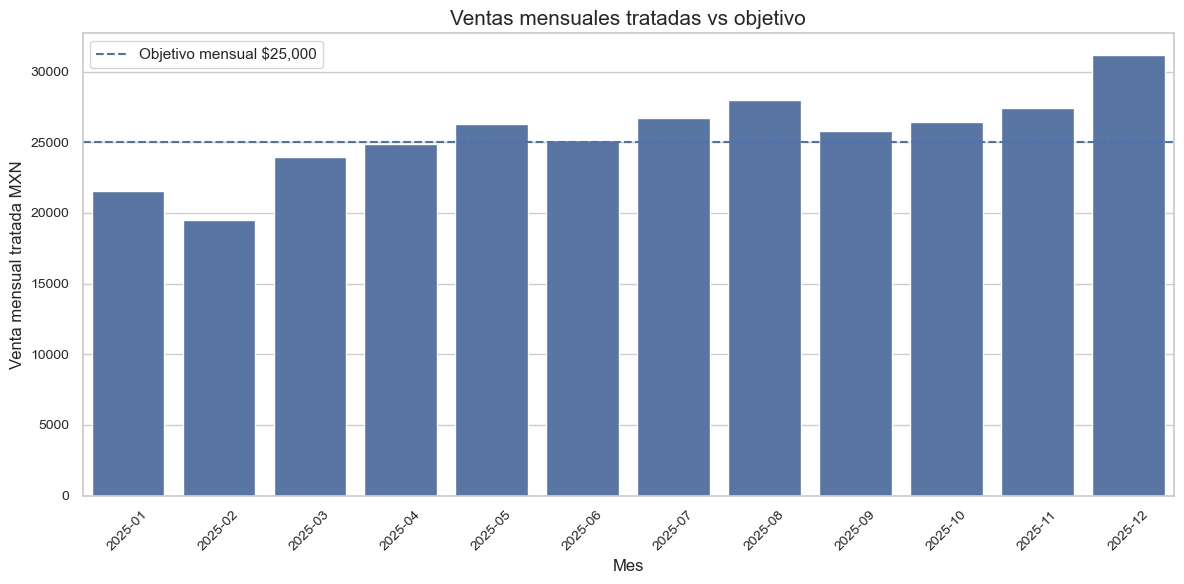

In [64]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=monthly_sales_treated,
    x="analysis_month",
    y="monthly_sales_treated_mxn"
)

plt.axhline(
    monthly_sales_target,
    linestyle="--",
    label="Objetivo mensual $25,000"
)

plt.title("Ventas mensuales tratadas vs objetivo")
plt.xlabel("Mes")
plt.ylabel("Venta mensual tratada MXN")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Insight post-tratamiento

Después del tratamiento, la venta diaria promedio quedó en aproximadamente $831.60 MXN, con una mediana de $815.00 MXN.

La cercanía entre media y mediana indica que la distribución quedó mucho más estable después de eliminar o limitar los valores extremos.

Antes del tratamiento, la venta mensual promedio estaba inflada por registros atípicos. Después del tratamiento, las ventas mensuales deberían acercarse de forma más razonable al objetivo operativo de $25,000 MXN mensuales.

Este resultado confirma que los outliers tenían un impacto relevante sobre las métricas principales del negocio.

## 20. Comparación antes vs después del tratamiento

Para evaluar el impacto de la limpieza y el tratamiento de outliers, se comparan las principales métricas antes y después del proceso.

Esta comparación permite demostrar cómo los errores y valores extremos pueden distorsionar la interpretación del desempeño de una máquina vending.

In [65]:
# Comparación antes vs después del tratamiento
before_after_summary = pd.DataFrame({
    "metrica": [
        "Registros",
        "Venta total MXN",
        "Venta diaria promedio MXN",
        "Venta diaria mediana MXN",
        "Venta diaria máxima MXN",
        "Litros totales",
        "Litros promedio por día",
        "Ticket promedio MXN"
    ],
    "antes_tratamiento": [
        len(df_treatment),
        df_treatment["total_gross_sales_mxn"].sum(),
        df_treatment["total_gross_sales_mxn"].mean(),
        df_treatment["total_gross_sales_mxn"].median(),
        df_treatment["total_gross_sales_mxn"].max(),
        df_treatment["total_liters_sold"].sum(),
        df_treatment["total_liters_sold"].mean(),
        df_treatment["avg_ticket_mxn"].mean()
    ],
    "despues_tratamiento": [
        len(df_clean),
        df_clean["total_gross_sales_mxn_treated"].sum(),
        df_clean["total_gross_sales_mxn_treated"].mean(),
        df_clean["total_gross_sales_mxn_treated"].median(),
        df_clean["total_gross_sales_mxn_treated"].max(),
        df_clean["total_liters_sold_treated"].sum(),
        df_clean["total_liters_sold_treated"].mean(),
        df_clean["avg_ticket_mxn"].mean()
    ]
})

before_after_summary["diferencia"] = (
    before_after_summary["despues_tratamiento"] -
    before_after_summary["antes_tratamiento"]
)

before_after_summary

,metrica,antes_tratamiento,despues_tratamiento,diferencia
0,Registros,376.00,369.00,-7.00
1,Venta total MXN,"341,179.00","306,860.00","-34,319.00"
2,Venta diaria promedio MXN,907.39,831.60,-75.79
3,Venta diaria mediana MXN,815.00,815.00,0.00
4,Venta diaria máxima MXN,"20,000.00","1,965.00","-18,035.00"
5,Litros totales,"14,930.00","13,869.00","-1,061.00"
6,Litros promedio por día,39.71,37.59,-2.12
7,Ticket promedio MXN,41.59,41.37,-0.22


In [66]:
# Impacto del tratamiento sobre la venta máxima
max_sales_before = df_treatment["total_gross_sales_mxn"].max()
max_sales_after = df_clean["total_gross_sales_mxn_treated"].max()

reduction_max_sales_pct = (max_sales_before - max_sales_after) / max_sales_before

print(f"Venta máxima antes del tratamiento: ${max_sales_before:,.2f} MXN")
print(f"Venta máxima después del tratamiento: ${max_sales_after:,.2f} MXN")
print(f"Reducción del valor máximo: {reduction_max_sales_pct:.2%}")

Venta máxima antes del tratamiento: $20,000.00 MXN
Venta máxima después del tratamiento: $1,965.00 MXN
Reducción del valor máximo: 90.18%


### Insight comparativo

La comparación antes y después muestra que los valores extremos tenían un impacto importante en las métricas del negocio.

El cambio más relevante se observa en la venta máxima diaria. Antes del tratamiento existían registros extremadamente altos que no representaban el comportamiento típico de una máquina vending.

Después del tratamiento, la venta máxima quedó en un rango más razonable para la operación diaria, lo que permite interpretar mejor el desempeño real del punto de venta.

## 21. Conclusión ejecutiva

El análisis exploratorio permitió evaluar el comportamiento diario de una máquina vending de productos de limpieza ubicada en CDMX.

El dataset fue diseñado con una venta mensual objetivo cercana a $25,000 MXN, pagos únicamente en efectivo, venta por litro completo y tanques de 100 litros por producto.

Durante la primera revisión se identificaron registros con problemas de calidad, incluyendo una fecha inválida, valores extremos, ventas inconsistentes y registros que distorsionaban el comportamiento promedio de la operación.

Las visualizaciones diagnósticas mostraron una distribución sesgada a la derecha, causada por días con ventas extremadamente altas. El boxplot confirmó la presencia de outliers relevantes, especialmente registros cercanos a $10,000 y $20,000 MXN.

Para tratar estos casos, se aplicó una metodología basada en tres decisiones:

- `Drop`: eliminar valores imposibles o inconsistentes.
- `Keep`: conservar valores extremos válidos.
- `Cap`: limitar valores extremos posibles mediante winsorización.

Después del tratamiento, el dataset quedó con 369 registros. La venta diaria promedio tratada fue de aproximadamente $831.60 MXN, con una mediana de $815.00 MXN. Esta cercanía entre media y mediana indica que la distribución quedó más estable y menos afectada por valores extremos.

La venta máxima diaria tratada quedó en $1,965.00 MXN, un valor mucho más razonable que los extremos observados antes del tratamiento.

Desde una perspectiva de negocio, el análisis demuestra que los outliers pueden cambiar significativamente la interpretación de una operación comercial. Si no se tratan correctamente, pueden inflar ventas promedio, alterar conclusiones mensuales y generar una lectura equivocada del desempeño real.

### Recomendaciones

1. Monitorear diariamente ventas, litros vendidos y tickets estimados.
2. Validar automáticamente que la venta bruta coincida con los litros vendidos por producto.
3. Revisar inconsistencias de efectivo, especialmente diferencia entre efectivo recibido, cambio entregado y venta bruta.
4. Usar reglas de negocio antes de eliminar outliers.
5. Mantener una clasificación clara entre valores imposibles, valores extremos válidos y valores extremos tratables.
6. Evaluar el desempeño mensual contra el objetivo de $25,000 MXN después de limpiar la base.

### Resultado final

Este proyecto demuestra un flujo completo de análisis exploratorio de datos aplicado a un caso operativo realista.

El notebook cubre carga de datos, limpieza, validación de reglas de negocio, estadísticas descriptivas, visualización diagnóstica, detección formal de outliers, tratamiento de datos y conclusión ejecutiva.

El análisis permite transformar una base de ventas diaria con errores intencionales en una fuente más confiable para tomar decisiones comerciales y operativas.